In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns 
import os

In [9]:
# =========================================================
# 1. LOAD DATA
# =========================================================
def load_data(filepath):
    if not os.path.exists(filepath):
        print(f"❌ File tidak ditemukan: {filepath}")
        return None
    try:
        df = pd.read_csv(filepath, index_col='date')
        df.index = pd.to_datetime(df.index, utc=True, errors='coerce')
        df.index = df.index.tz_convert('Asia/Jakarta')
        df.index = df.index.tz_localize(None)
        df = df.sort_index()
        return df
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

In [ ]:
# =========================================================
# 2. FUNGSI ANALISIS DETAIL (DISIMPLIFIKASI)
# =========================================================
def analisis_detail(df, target_waktu):
    print(f"\nANALISIS DETAIL PERIODE: {target_waktu}")
    print("="*50)
    
    try:
        subset = df.loc[target_waktu]
        if subset.empty:
            print("⚠️ Data tidak ditemukan.")
            return

        # --- A. ANALISIS SUHU ---
        print("STATISTIK SUHU")
        
        # Hitung Rata-rata
        avg_temp = subset['temperature'].mean()
        
        # Cari Max & Min
        max_temp = subset['temperature'].max()
        max_temp_date = subset['temperature'].idxmax()
        min_temp = subset['temperature'].min()
        min_temp_date = subset['temperature'].idxmin()
        
        print(f"Rata-rata Suhu Bulanan: {avg_temp:.2f}°C") # <--- TAMBAHAN
        print(f"Suhu Maksimum: {max_temp:.2f}°C (pada {max_temp_date})")
        print(f"Suhu Minimum : {min_temp:.2f}°C (pada {min_temp_date})")
        print("-" * 30)        
        # Agregasi Harian
        harian = subset['rain_mm'].resample('D').sum()
        
        # 1. Total & Max
        total_hujan = harian.sum()
        max_hujan_sehari = harian.max()
        tgl_max_hujan = harian.idxmax().strftime('%Y-%m-%d')
        
        print(f"Total Curah Hujan : {total_hujan:.2f} mm")
        print(f"Rekor Curah Hujan   : {max_hujan_sehari:.2f} mm (Tgl {tgl_max_hujan})")
        
        # 2. Kategori Sederhana (Basah vs Kering)
        # Hari Basah: > 10 mm
        hari_basah = harian[harian > 10]
        jml_hari_basah = len(hari_basah)
        
        # Hari Kering: <= 10 mm (Termasuk 0 mm dan gerimis)
        hari_kering = harian[harian <= 10]
        jml_hari_kering = len(hari_kering)
        
        print(f"Jumlah Hari Basah (>10mm)  : {jml_hari_basah} hari")
        print(f"Jumlah Hari Kering (<=10mm): {jml_hari_kering} hari")
        
        print("="*50)

    except KeyError:
        print(f"❌ Format waktu salah. Gunakan 'YYYY' atau 'YYYY-MM'.")
    except Exception as e:
        print(f"⚠️ Error analisis: {e}")

In [38]:
# =========================================================
# 3. FUNGSI PLOTTING PERIODE TERTENTU (BULANAN/TAHUNAN)
# =========================================================
def plot_periode_tertentu(df, target_waktu):
    print(f"\nMenggambar grafik untuk periode: {target_waktu}...")
    try:
        # 1. Ambil subset data menggunakan .loc
        subset = df.loc[target_waktu].copy()
        
        if subset.empty:
            print("⚠️ Data kosong.")
            return

        # =========================================================
        # 🛡️ PENGAMANAN ZONA WAKTU (TIMEZONE FIX)
        # =========================================================
        # Pastikan index sudah berupa format Datetime
        if not pd.api.types.is_datetime64_any_dtype(subset.index):
            subset.index = pd.to_datetime(subset.index)
            
        # Matplotlib sering menggeser waktu yang memiliki timezone (+07:00) kembali ke UTC.
        # Kita hapus informasi timezone-nya (tz-localize None) khusus untuk plotting, 
        # agar jam yang tertera (misal 06:00 WIB) tetap tampil sebagai jam 06:00 di grafik.
        if subset.index.tz is not None:
            subset.index = subset.index.tz_localize(None)

        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # --- LOGIKA TAMPILAN BERDASARKAN PERIODE ---
        
        # KASUS 1: TAMPILAN HARIAN (YYYY-MM-DD) -> Tampilkan Detail Menit/Jam
        if len(str(target_waktu)) > 7: 
            ax1.plot(subset.index, 
                     subset['temperature'], 
                     color='darkorange', 
                     linestyle='-', 
                     linewidth=2, 
                     label='Suhu (°C)')
            
            ax2 = ax1.twinx()
            ax2.bar(subset.index, 
                    subset['rain_mm'], 
                    color='dodgerblue', 
                    alpha=0.5, 
                    width=0.004, 
                    label='Hujan (mm)', 
                    align='center')
            
            # Format waktu jam dan menit yang aman
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            ax1.set_xlabel('Jam (WIB)')
            judul = f"Cuaca Detail Tanggal: {target_waktu}"

        # KASUS 2: TAMPILAN BULANAN (YYYY-MM) -> Rata-rata Suhu Harian & Total Hujan Harian
        elif len(str(target_waktu)) == 7:
            # 1. Resample Suhu jadi Rata-rata Harian
            suhu_harian = subset['temperature'].resample('D').mean()
            
            # Plot Suhu Harian (Garis dengan titik/marker)
            ax1.plot(suhu_harian.index, suhu_harian, 
                     color='darkorange', marker='o', markersize=4, linewidth=2, label='Rata-rata Suhu Harian (°C)')
            
            # 2. Resample Hujan jadi Total Harian
            ax2 = ax1.twinx()
            hujan_harian = subset['rain_mm'].resample('D').sum()
            
            # Plot Hujan Harian (Batang)
            ax2.bar(hujan_harian.index, hujan_harian, 
                    color='dodgerblue', alpha=0.6, width=0.8, label='Total Hujan Harian (mm)')
            
            # Format Sumbu X (Menampilkan Tanggal Saja)
            ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Label tiap 2 hari biar rapi
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
            ax1.set_xlabel(f'Tanggal (Bulan: {target_waktu})')
            judul = f"Tren Cuaca Harian selama Bulan: {target_waktu}"

        # KASUS 3: TAMPILAN TAHUNAN (YYYY) -> Agregasi Bulanan
        else:
            suhu_bulanan = subset['temperature'].resample('ME').mean()
            ax1.plot(suhu_bulanan.index, suhu_bulanan, 
                     color='darkorange', marker='o', linewidth=2, label='Rata-rata Suhu Bulanan (°C)')
            
            ax2 = ax1.twinx()
            hujan_bulanan = subset['rain_mm'].resample('ME').sum()
            
            # Width=20 agar batang menempati porsi besar di sumbu x bulanan
            ax2.bar(hujan_bulanan.index, hujan_bulanan, 
                    color='dodgerblue', alpha=0.6, width=20, label='Total Hujan Bulanan (mm)')
            
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
            ax1.set_xlabel('Bulan')
            judul = f"Tren Cuaca Bulanan Tahun: {target_waktu}"

        # --- FORMATTING UMUM ---
        ax1.set_ylabel('Suhu (°C)', color='darkorange', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='darkorange')
        ax1.grid(True, linestyle='--', alpha=0.5)

        ax2.set_ylabel('Curah Hujan (mm)', color='dodgerblue', fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='dodgerblue')
        ax2.set_ylim(bottom=0)

        plt.title(judul, fontweight='bold', fontsize=14)
        
        # Menggabungkan Legend dari 2 axis
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
        
        plt.tight_layout()
        
        # =========================================================
        # 3. MENYIMPAN PLOT
        # =========================================================
        output_folder = 'periode_tertentu_plots'
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)

        filename = f"Periode_{target_waktu}.png"
        filepath = os.path.join(output_folder, filename)
        
        # Simpan grafik
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"✅ Grafik Hyetograph berhasil disimpan di: {filepath}")
        
        # Tampilkan grafik di layar
        plt.show()
        
    except Exception as e:
        print(f"⚠️ Terjadi error saat plotting: {e}")

In [3]:
# =========================================================
# 4. FUNGSI PLOTTING HARIAN (DETAIL JAM)
# =========================================================
def plot_harian(df, target_tanggal):
    """
    Plotting khusus untuk satu hari penuh (00:00 - 23:00).
    Format target_tanggal: 'YYYY-MM-DD' (Contoh: '2022-11-05')
    """
    print(f"\n🎨 Menggambar grafik detail harian: {target_tanggal}...")
    
    try:
        # Slicing data (Partial String Indexing)
        subset = df.loc[target_tanggal]
        
        if subset.empty:
            print(f"⚠️ Data kosong untuk tanggal {target_tanggal}")
            return

        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # --- 1. PLOT SUHU (GARIS) ---
        ax1.plot(subset.index, subset['temperature'], 
                 color='#FF4500', linewidth=2, marker='o', markersize=4, label='Suhu (°C)')
        ax1.set_ylabel('Suhu (°C)', color='#FF4500', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='#FF4500')
        ax1.grid(True, linestyle='--', alpha=0.3)
        
        # Tandai Suhu Maksimum dengan Titik Besar & Teks
        max_temp = subset['temperature'].max()
        max_temp_time = subset['temperature'].idxmax()
        ax1.annotate(f'Max: {max_temp}°C', 
                     xy=(max_temp_time, max_temp), 
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', color='red', fontweight='bold')

        # --- 2. PLOT HUJAN (BAR) ---
        ax2 = ax1.twinx()
        ax2.bar(subset.index, subset['rain_mm'], 
                color='#00BFFF', alpha=0.5, width=0.03, label='Hujan (mm)')
        ax2.set_ylabel('Hujan (mm)', color='#00BFFF', fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='#00BFFF')
        
        # Atur batas atas hujan biar barnya tidak menutupi grafik suhu
        max_rain = subset['rain_mm'].max()
        top_limit = max_rain * 2 if max_rain > 0 else 10
        ax2.set_ylim(0, top_limit)

        # --- 3. FORMAT SUMBU X (JAM) ---
        # Format label jam: 00:00, 03:00, dst
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3)) # Interval tiap 3 jam
        ax1.set_xlabel('Waktu (WIB)', fontweight='bold')
        
        # Judul
        plt.title(f"Dinamika Cuaca Harian: {target_tanggal}", fontsize=14, fontweight='bold', pad=15)
        
        # Legend Gabungan
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
        
        plt.tight_layout()
        plt.show()

    except KeyError:
        print("❌ Format tanggal salah. Gunakan 'YYYY-MM-DD'.")
    except Exception as e:
        print(f"⚠️ Error plotting harian: {e}")

In [39]:
def plot_hyetograph_bulanan(df, target_waktu):
    """
    Fungsi untuk membuat Hyetograph Bulanan (Curah Hujan Harian & Kumulatif).
    df: DataFrame yang memiliki index datetime (WIB) dan kolom curah hujan.
    target_waktu: String format 'YYYY-MM' (contoh: '2026-02')
    """
    print(f"\n🌧️ Membuat Hyetograph Bulanan untuk periode: {target_waktu}...")
    
    # 1. FILTER & PREPARASI DATA
    try:
        # Ambil data spesifik pada bulan tersebut
        df_bulan = df.loc[target_waktu].copy()
        
        if df_bulan.empty:
            print(f"⚠️ Data untuk {target_waktu} kosong.")
            return

        # =========================================================
        # 🛡️ PENGAMANAN ZONA WAKTU (TIMEZONE FIX)
        # =========================================================
        # Pastikan index sudah berupa format Datetime
        if not pd.api.types.is_datetime64_any_dtype(df_bulan.index):
            df_bulan.index = pd.to_datetime(df_bulan.index)
            
        # Hapus informasi timezone (+07:00) agar saat di-resample harian ('D') 
        # dan di-plot, Matplotlib tidak menggesernya kembali ke UTC (hari sebelumnya).
        if df_bulan.index.tz is not None:
            df_bulan.index = df_bulan.index.tz_localize(None)

        # Pastikan kita memproses data hujan
        if 'curah_hujan' in df_bulan.columns:
            hujan_harian = df_bulan['curah_hujan'].resample('D').sum()
        elif 'rain_mm' in df_bulan.columns:
            hujan_harian = df_bulan['rain_mm'].resample('D').sum()
        elif 'rainrate' in df_bulan.columns:
            hujan_harian = df_bulan['rainrate'].resample('D').sum()
        else:
            print("❌ Kolom hujan tidak ditemukan. Pastikan ada 'curah_hujan', 'rain_mm', atau 'rainrate'.")
            return

        # Handling nilai NaN (Jika ada hari tanpa hujan sama sekali)
        hujan_harian = hujan_harian.fillna(0)

        # Hitung Hujan Kumulatif Bulanan
        kumulatif_hujan = hujan_harian.cumsum()

    except KeyError:
        print("❌ Format waktu salah atau data tidak ada. Gunakan 'YYYY-MM' (contoh: '2026-02').")
        return
    except Exception as e:
        print(f"❌ Terjadi error: {e}")
        return

    # 2. PROSES PLOTTING
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Ekstrak label tanggal (1, 2, 3... dst) dengan aman
    tanggal_labels = hujan_harian.index.strftime('%d')
    x_pos = range(len(tanggal_labels))

    # --- AXIS 1: HYETOGRAPH (BATANG HARIAN) ---
    ax1.bar(x_pos, hujan_harian, color='dodgerblue', edgecolor='navy', alpha=0.75, width=0.7, label='Curah Hujan Harian')
    
    ax1.set_xlabel('Tanggal', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Curah Hujan Harian (mm)', fontsize=12, color='navy', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='navy')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(tanggal_labels)
    ax1.set_ylim(bottom=0)

    # Garis Batas Kategori Hujan BMKG
    ax1.axhline(y=20, color='gold', linestyle='--', linewidth=1.5, alpha=0.8, label='Hujan Sedang (20mm)')
    ax1.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, alpha=0.8, label='Hujan Lebat (50mm)')
    ax1.axhline(y=100, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Hujan Sangat Lebat (100mm)')

    # --- AXIS 2: KUMULATIF BULANAN (GARIS) ---
    ax2 = ax1.twinx()
    ax2.plot(x_pos, kumulatif_hujan, color='darkgreen', marker='o', linestyle='-', linewidth=2.5, markersize=6, label='Hujan Kumulatif')
    
    ax2.set_ylabel('Akumulasi Curah Hujan Bulanan (mm)', fontsize=12, color='darkgreen', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='darkgreen')
    ax2.set_ylim(bottom=0)

    # Beri anotasi (Teks) untuk Total Hujan di akhir bulan
    total_sebulan = kumulatif_hujan.iloc[-1]
    ax2.annotate(f'Total Bulan Ini:\n{total_sebulan:.1f} mm', 
                 xy=(x_pos[-1], total_sebulan), 
                 xytext=(-60, 15), textcoords='offset points',
                 color='white', backgroundcolor='darkgreen', 
                 fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="darkgreen", ec="darkgreen", lw=1))

    # --- FORMATTING & KOSMETIK ---
    # Ubah format nama bulan ke Bahasa Indonesia
    indonesian_months = {
        1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April',
        5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus',
        9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
    }
    
    first_dt = hujan_harian.index[0]
    nama_bulan = f"{indonesian_months.get(first_dt.month, first_dt.strftime('%B'))} {first_dt.year}"
    plt.title(f'Akumulasi Curah Hujan\nPeriode: {nama_bulan}', fontsize=15, fontweight='bold')
    
    # Grid hanya untuk sumbu Y (Harian)
    ax1.grid(axis='y', linestyle=':', alpha=0.5)

    # Gabung Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.01, 0.98), framealpha=0.9)

    plt.tight_layout()

    # 3. MENYIMPAN PLOT
    output_folder = 'plots_hyetograph_bulanan'
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    filename = f"Hyetograph_Bulanan_{target_waktu}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"✅ Grafik Hyetograph berhasil disimpan di: {filepath}")

    plt.show()

# =========================================================
# CARA PENGGUNAAN:
# plot_hyetograph_bulanan(df_cuaca, '2026-04') 
# =========================================================


ANALISIS DETAIL PERIODE: 2025-03
STATISTIK SUHU
Rata-rata Suhu Bulanan: 27.79°C
Suhu Maksimum: 32.70°C (pada 2025-03-26 13:00:00)
Suhu Minimum : 23.70°C (pada 2025-03-20 04:00:00)
------------------------------
Total Curah Hujan : 277.50 mm
Rekor Curah Hujan   : 62.70 mm (Tgl 2025-03-09)
Jumlah Hari Basah (>10mm)  : 8 hari
Jumlah Hari Kering (<=10mm): 23 hari

Menggambar grafik untuk periode: 2025-03...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-03.png


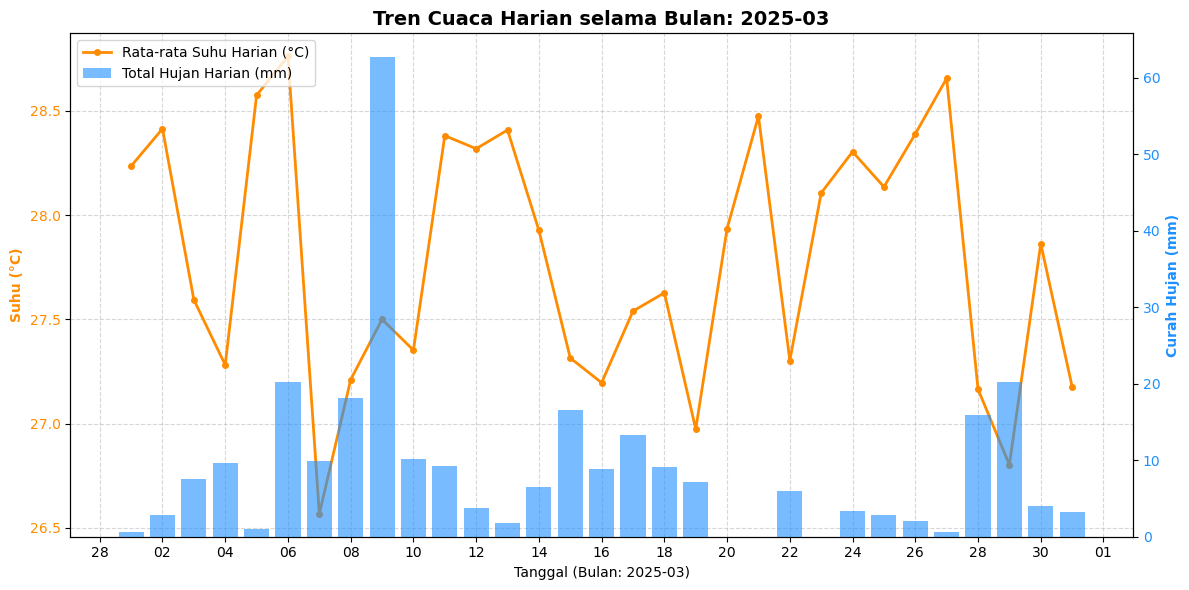

In [40]:
# 1. Deteksi environment (Kaggle vs Lokal)
cwd = os.getcwd()

if "/kaggle" in cwd:
    # Base folder jika dijalankan di Kaggle
    BASE_DIR = os.path.join("/kaggle", "input", "datasets", "jerismeteo", "open-meteo-data-kebumen")
else:
    # Base folder jika dijalankan di laptop/komputer lokal
    BASE_DIR = cwd

# 2. Tentukan nama sub-folder dan file
FOLDER_DATA = "open_meteo_jerukagung"
NAMA_FILE = "cuaca_jerukagung.csv"

# 3. Gabungkan semua bagian menjadi satu path yang dinamis dan aman (bebas slash/backslash error)
PATH_FILE = os.path.join(BASE_DIR, FOLDER_DATA, NAMA_FILE)

if __name__ == "__main__":
    df_cuaca = load_data(PATH_FILE)
    
    if df_cuaca is not None:
        # Contoh Analisis YYYY-MM (Bulan yang akan datang, untuk melihat prediksi atau tren)
        TARGET = "2025-03"
        
        # 1. Tampilkan Angka Statistik
        analisis_detail(df_cuaca, TARGET)
        
        # 2. Tampilkan Grafik
        plot_periode_tertentu(df_cuaca, TARGET)


--- Memproses Data Bulan 2025-01 ---

Menggambar grafik untuk periode: 2025-01...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-01.png


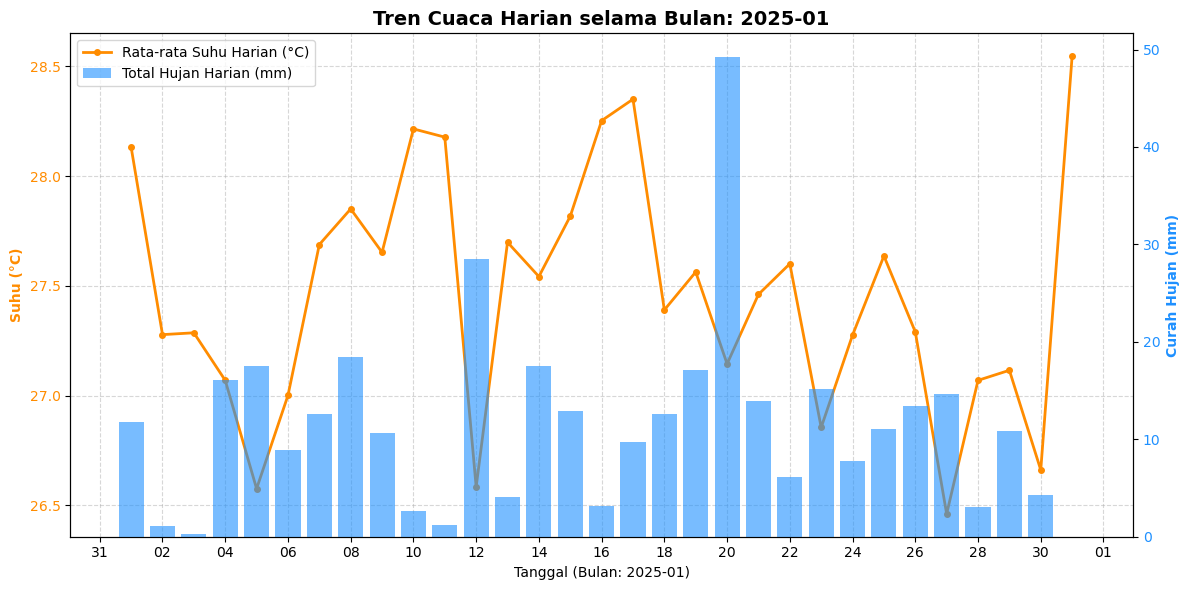


--- Memproses Data Bulan 2025-02 ---

Menggambar grafik untuk periode: 2025-02...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-02.png


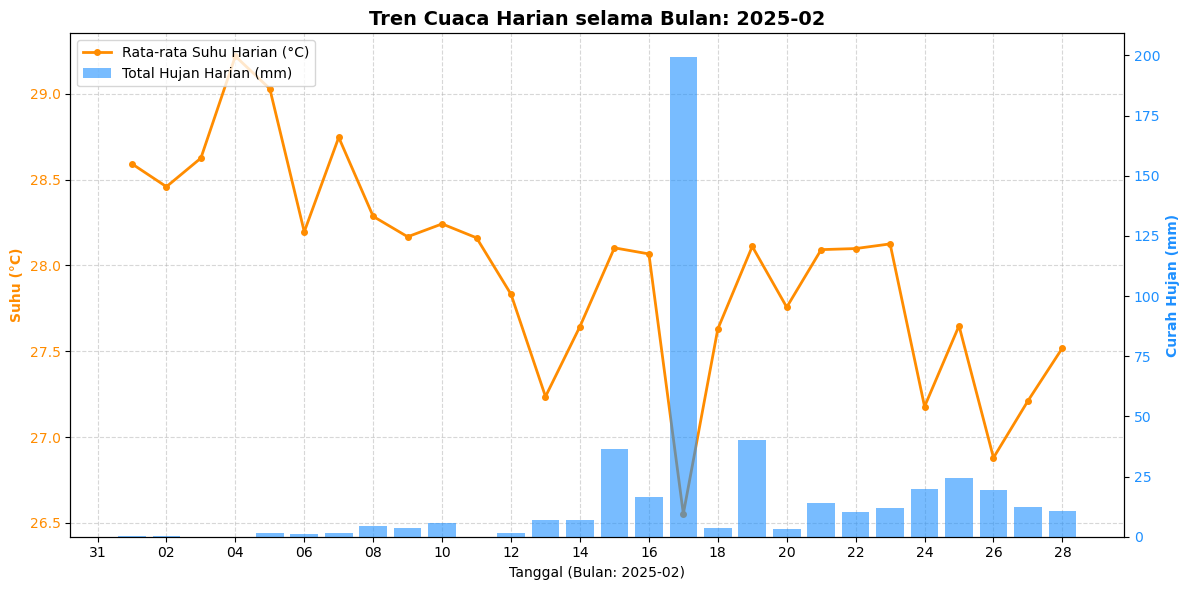


--- Memproses Data Bulan 2025-03 ---

Menggambar grafik untuk periode: 2025-03...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-03.png


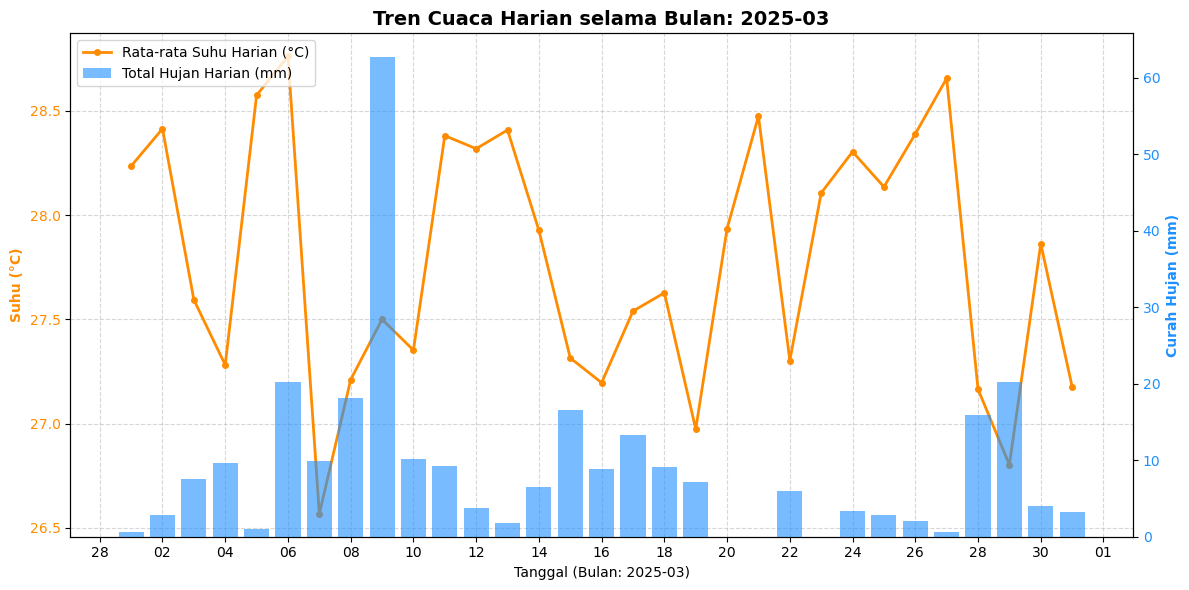


--- Memproses Data Bulan 2025-04 ---

Menggambar grafik untuk periode: 2025-04...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-04.png


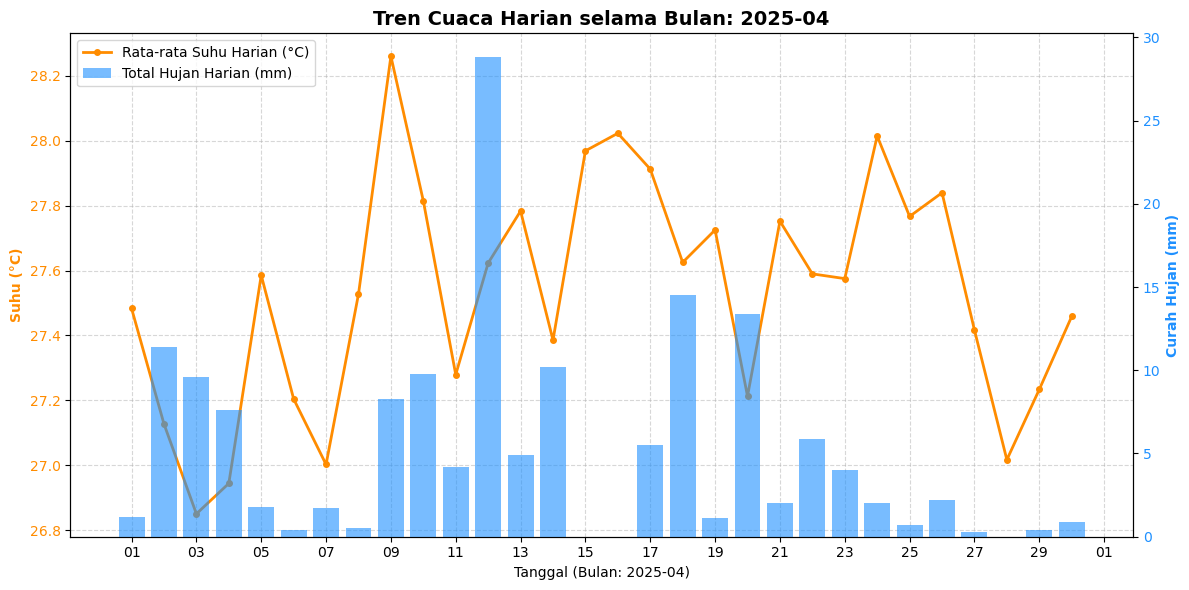


--- Memproses Data Bulan 2025-05 ---

Menggambar grafik untuk periode: 2025-05...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-05.png


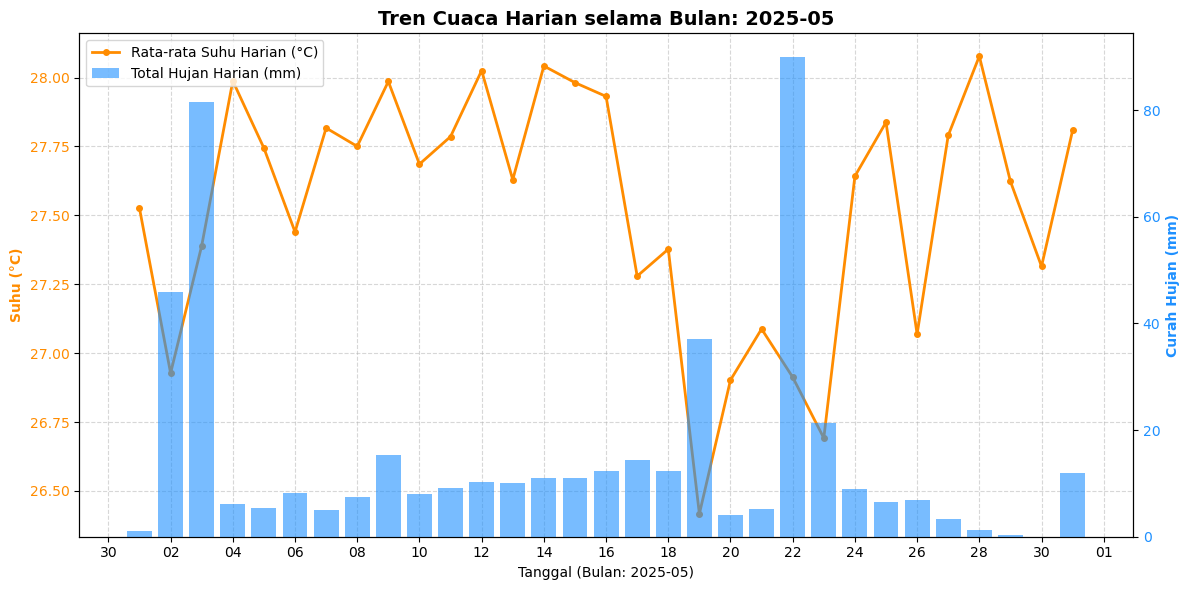


--- Memproses Data Bulan 2025-06 ---

Menggambar grafik untuk periode: 2025-06...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-06.png


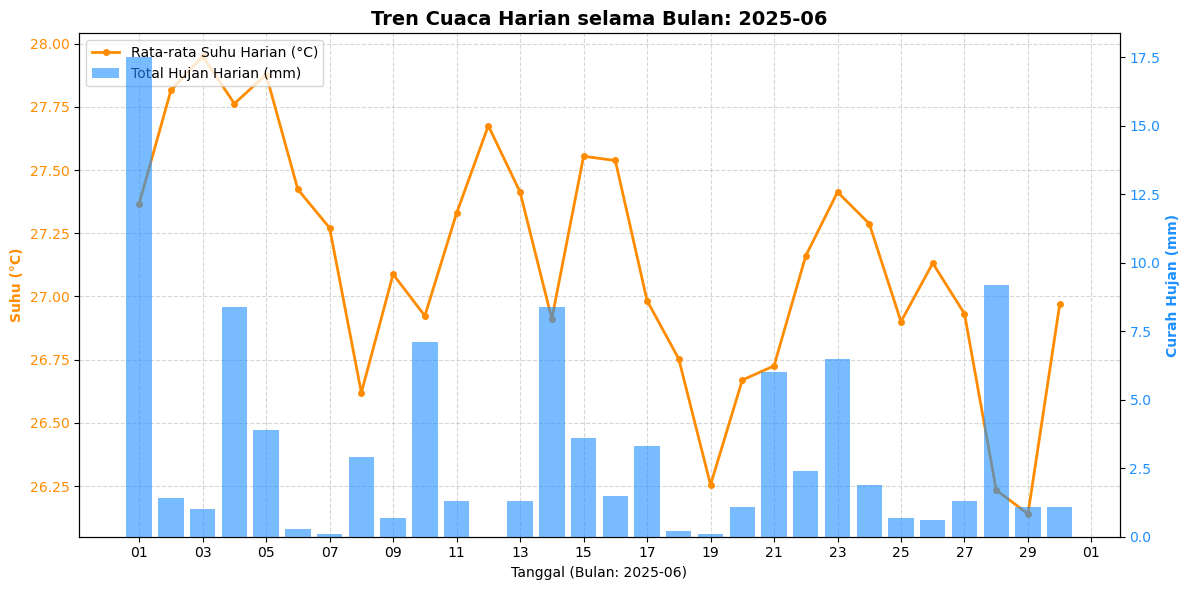


--- Memproses Data Bulan 2025-07 ---

Menggambar grafik untuk periode: 2025-07...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-07.png


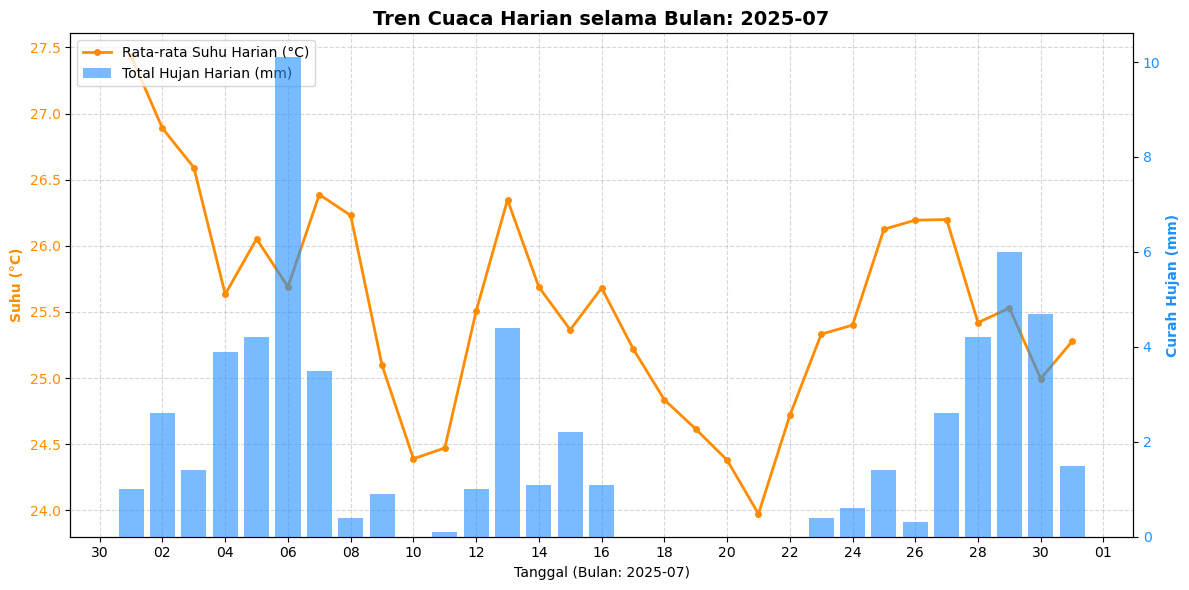


--- Memproses Data Bulan 2025-08 ---

Menggambar grafik untuk periode: 2025-08...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-08.png


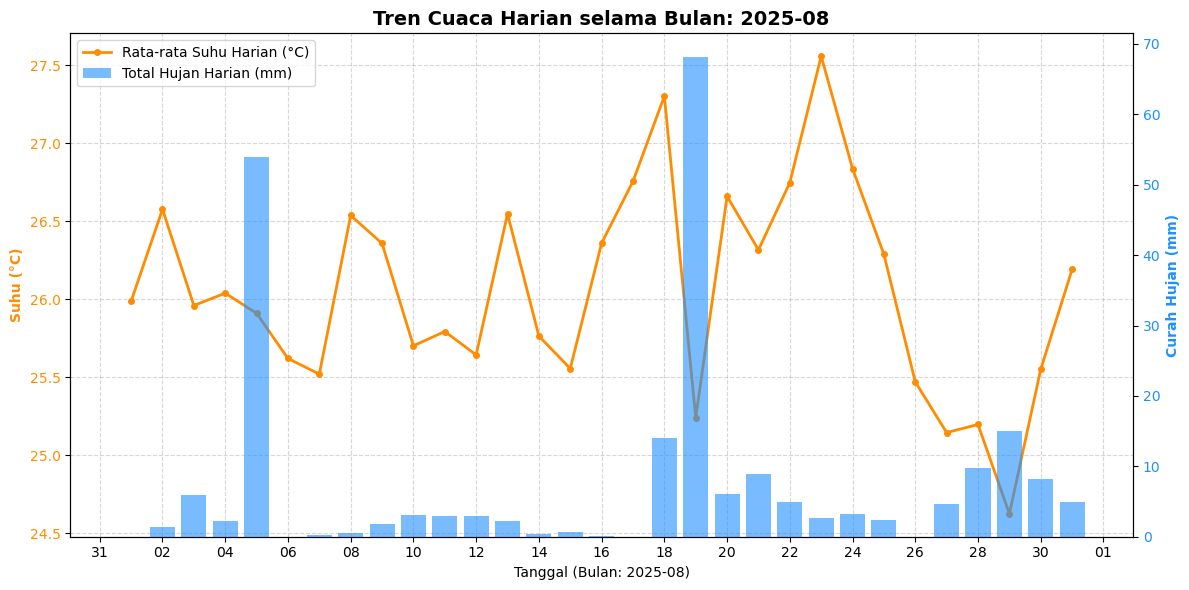


--- Memproses Data Bulan 2025-09 ---

Menggambar grafik untuk periode: 2025-09...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-09.png


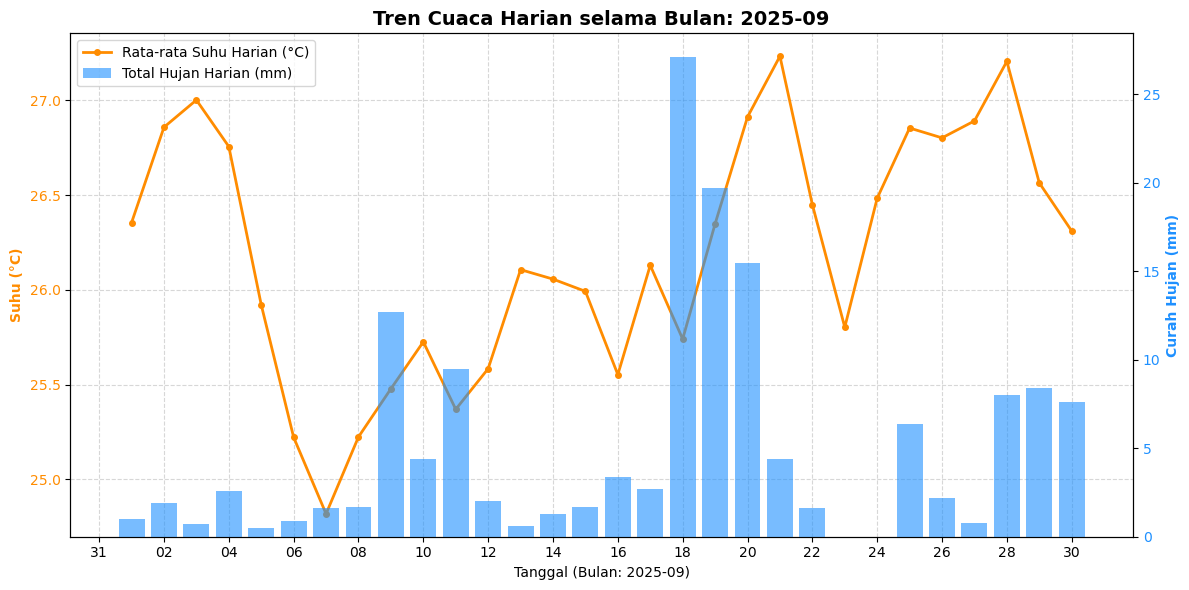


--- Memproses Data Bulan 2025-10 ---

Menggambar grafik untuk periode: 2025-10...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-10.png


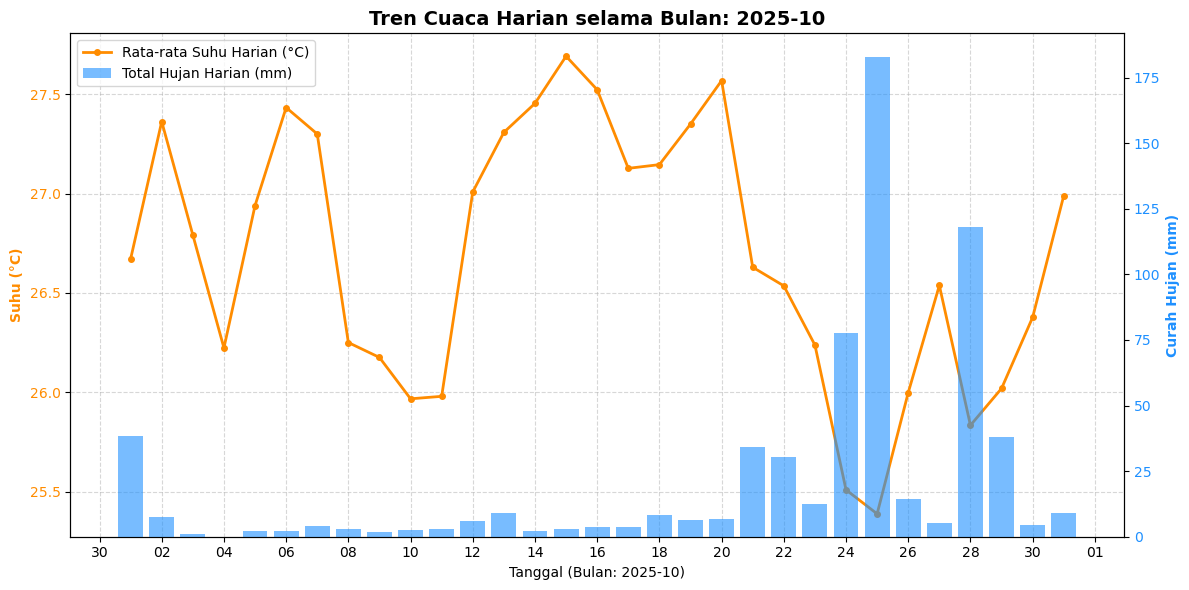


--- Memproses Data Bulan 2025-11 ---

Menggambar grafik untuk periode: 2025-11...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-11.png


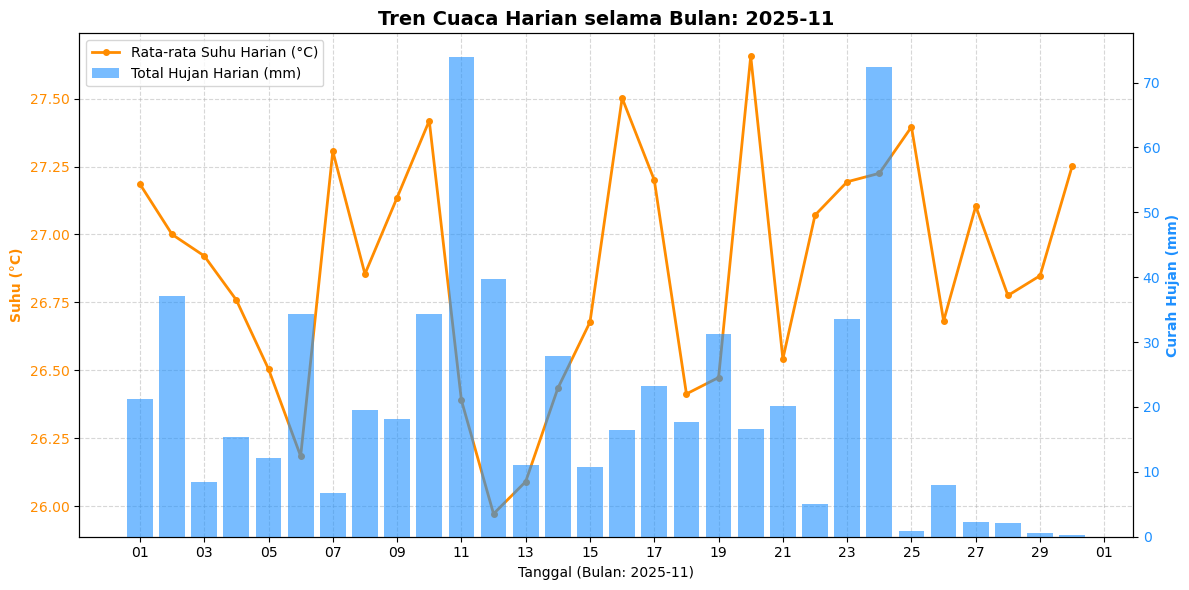


--- Memproses Data Bulan 2025-12 ---

Menggambar grafik untuk periode: 2025-12...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2025-12.png


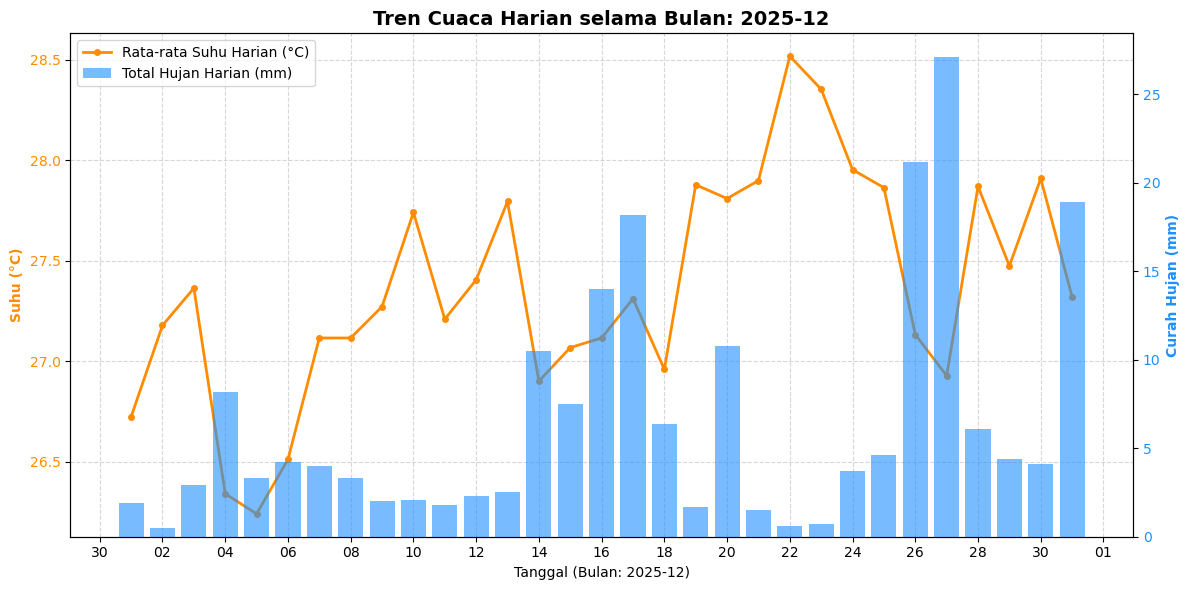


--- Memproses Data Bulan 2026-01 ---

Menggambar grafik untuk periode: 2026-01...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2026-01.png


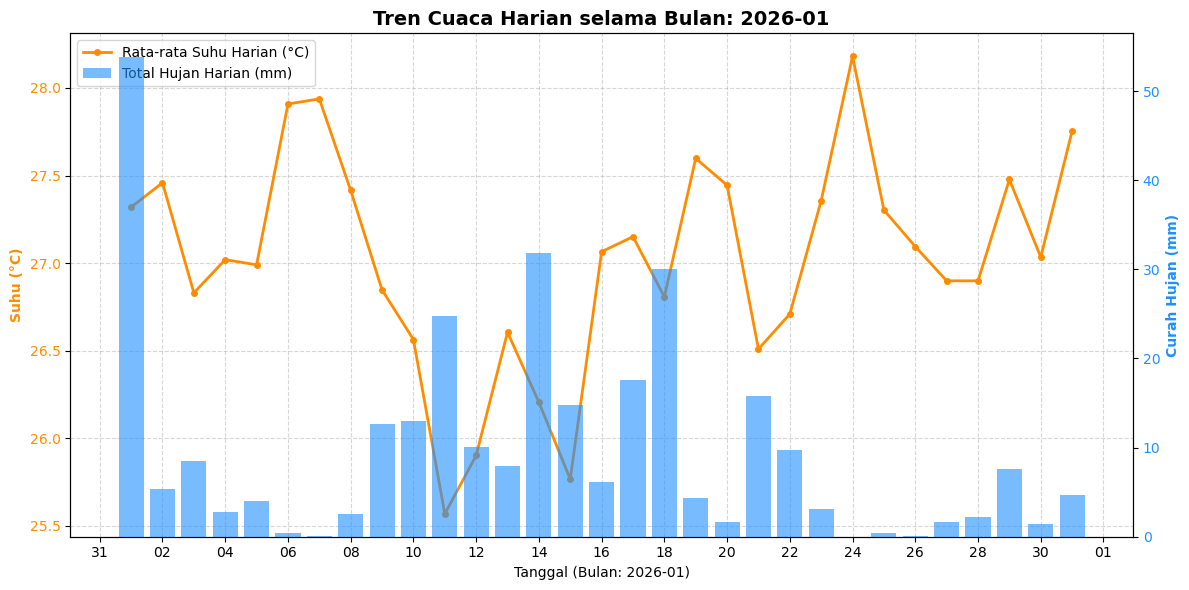


--- Memproses Data Bulan 2026-02 ---

Menggambar grafik untuk periode: 2026-02...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2026-02.png


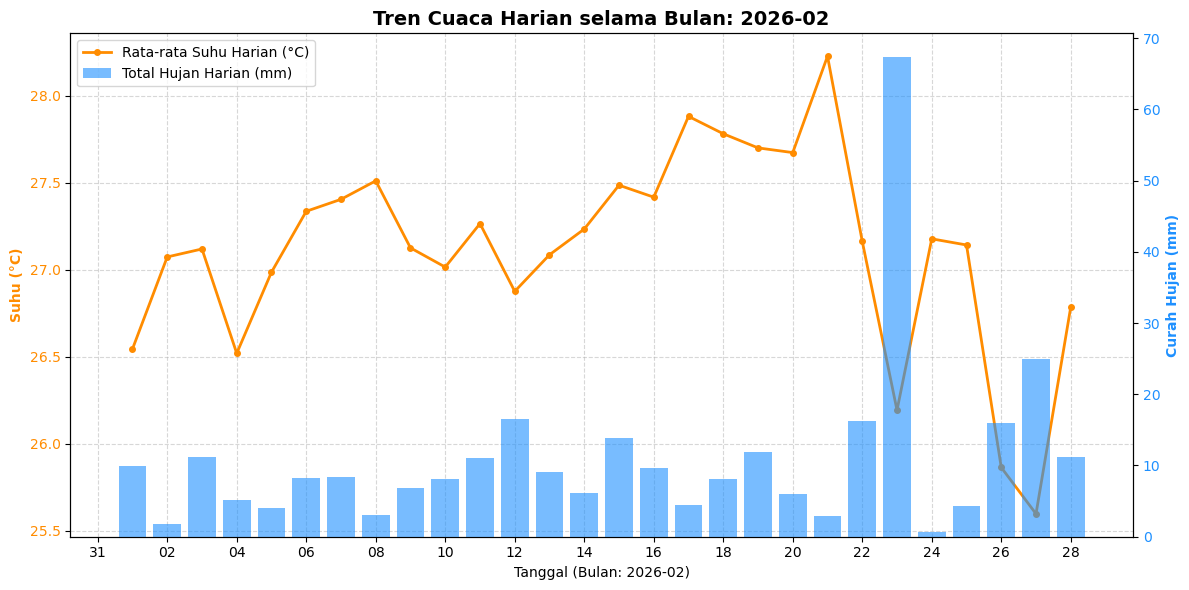


--- Memproses Data Bulan 2026-03 ---

Menggambar grafik untuk periode: 2026-03...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2026-03.png


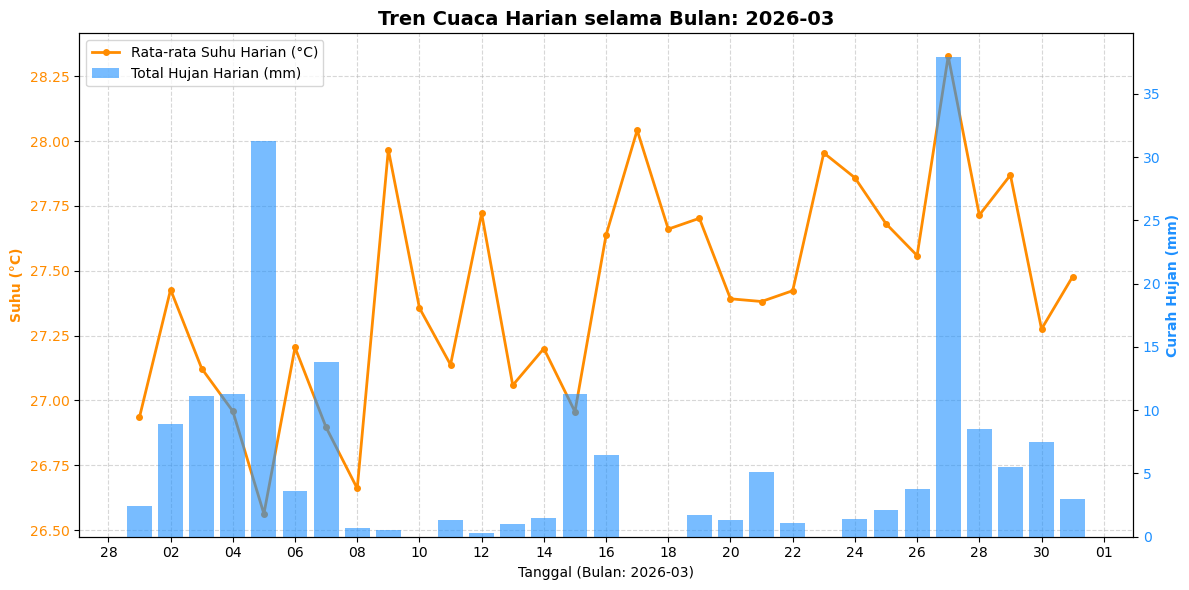


--- Memproses Data Bulan 2026-04 ---

Menggambar grafik untuk periode: 2026-04...
✅ Grafik Hyetograph berhasil disimpan di: periode_tertentu_plots\Periode_2026-04.png


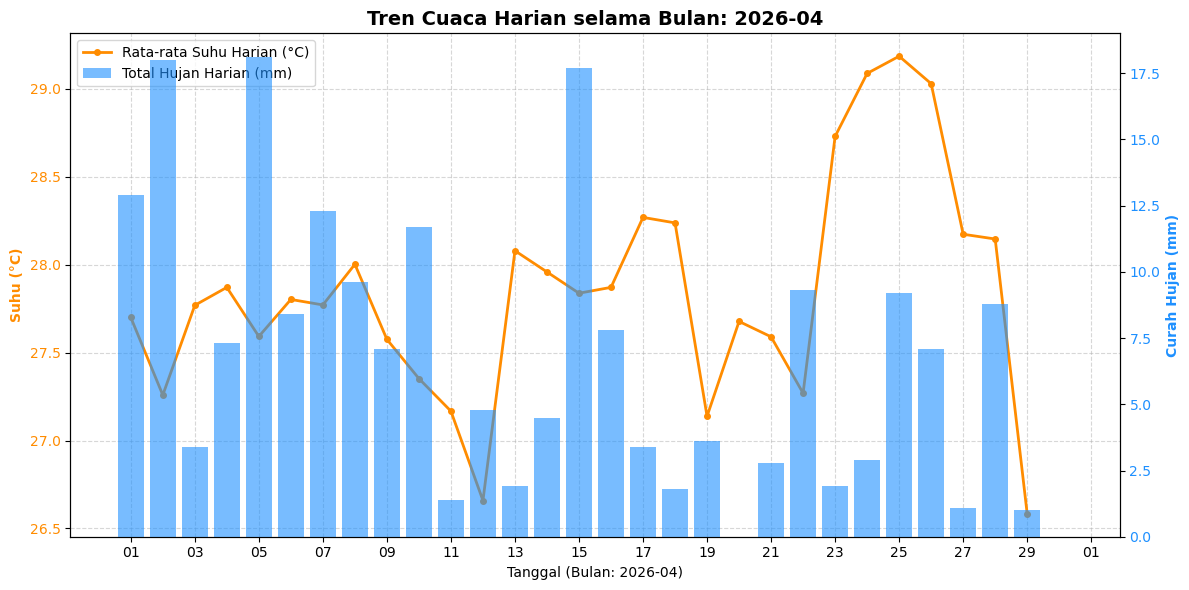

In [41]:
# 1. Deteksi environment (Kaggle vs Lokal)
cwd = os.getcwd()

if "/kaggle" in cwd:
    # Base folder jika dijalankan di Kaggle
    BASE_DIR = os.path.join("/kaggle", "input", "datasets", "jerismeteo", "open-meteo-data-kebumen")
else:
    # Base folder jika dijalankan di laptop/komputer lokal
    BASE_DIR = cwd

# 2. Tentukan nama sub-folder dan file
FOLDER_DATA = "open_meteo_jerukagung"
NAMA_FILE = "cuaca_jerukagung.csv"

# 3. Gabungkan semua bagian menjadi satu path yang dinamis dan aman (bebas slash/backslash error)
PATH_FILE = os.path.join(BASE_DIR, FOLDER_DATA, NAMA_FILE)

if __name__ == "__main__":
    df_cuaca = load_data(PATH_FILE)
    
    if df_cuaca is not None:
        # Ubah TARGET menjadi sebuah List berisi beberapa bulan
        TARGETS = [
            "2025-01", 
            "2025-02",
            "2025-03",
            "2025-04",
            "2025-05",
            "2025-06",
            "2025-07",
            "2025-08",
            "2025-09",
            "2025-10",
            "2025-11",
            "2025-12",
            "2026-01", 
            "2026-02", 
            "2026-03", 
            "2026-04"
            ]
        
        # Lakukan perulangan untuk setiap bulan di dalam list
        for target_bulan in TARGETS:
            print(f"\n--- Memproses Data Bulan {target_bulan} ---")
            plot_periode_tertentu(df_cuaca, target_bulan)


--- Memproses Data Bulan 2025-01 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-01...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-01.png


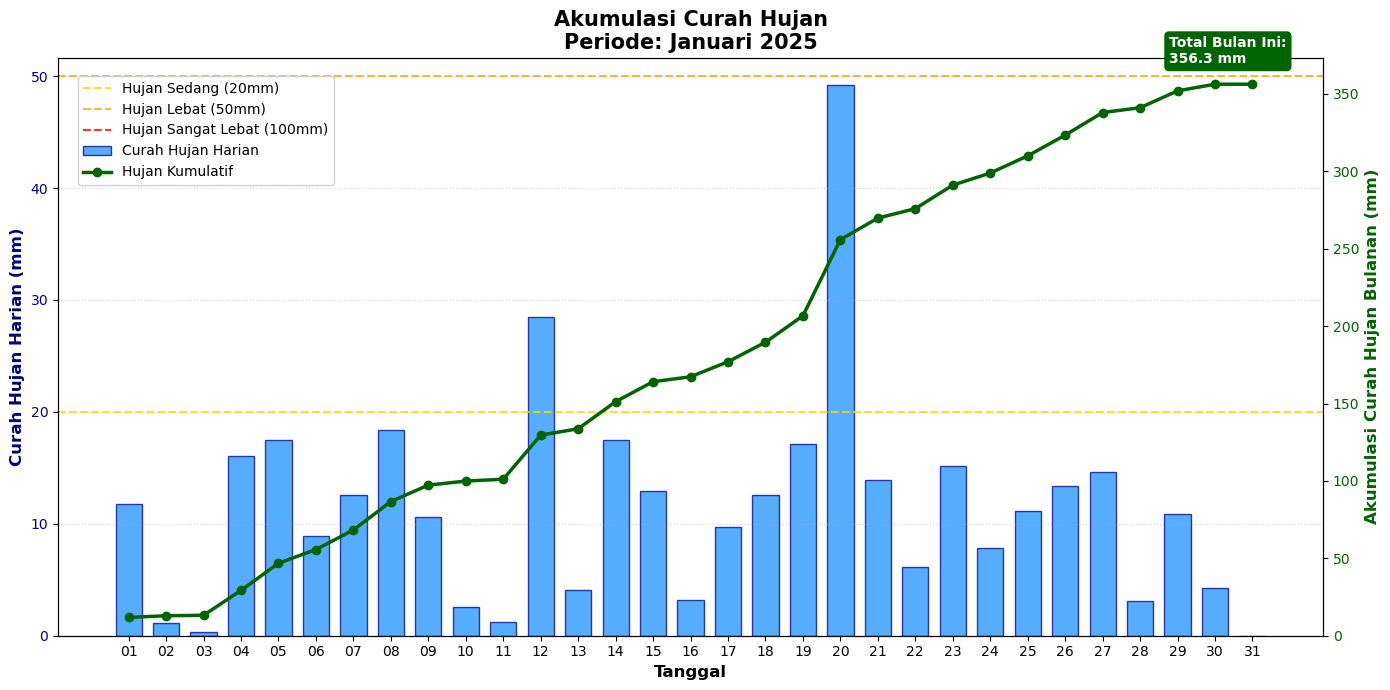


--- Memproses Data Bulan 2025-02 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-02...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-02.png


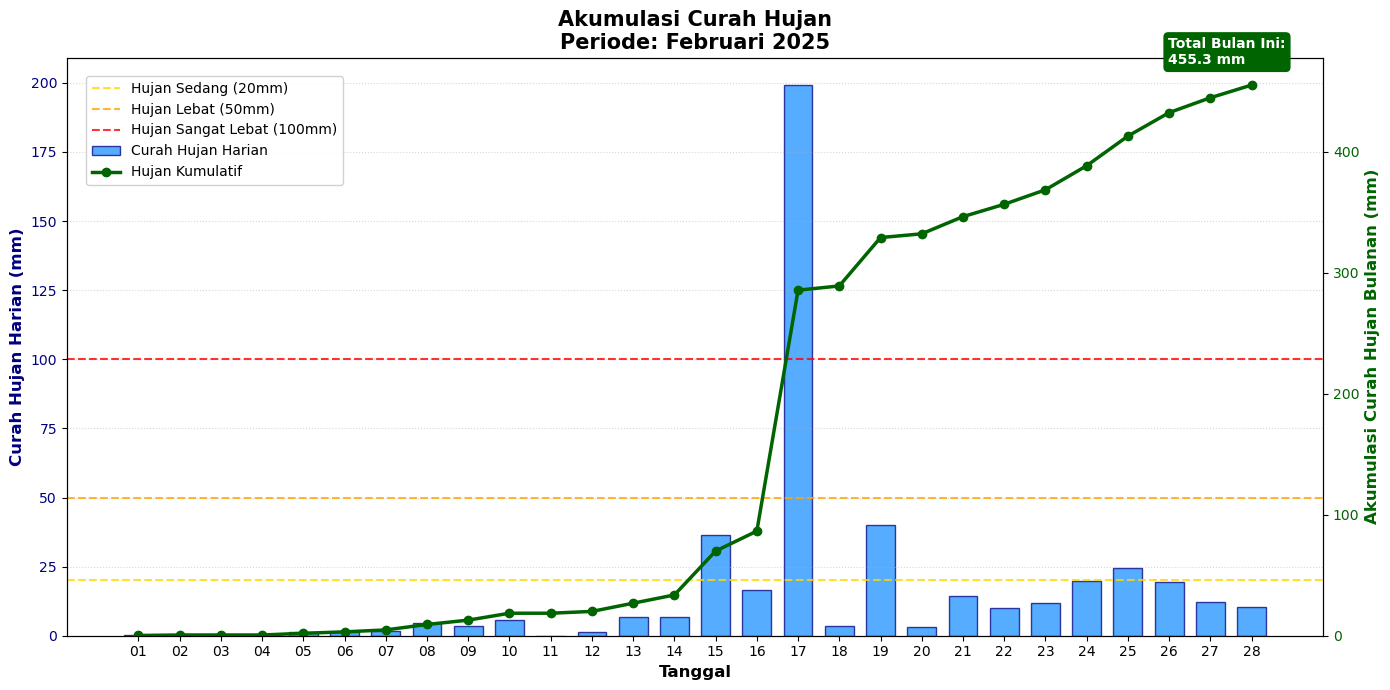


--- Memproses Data Bulan 2025-03 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-03...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-03.png


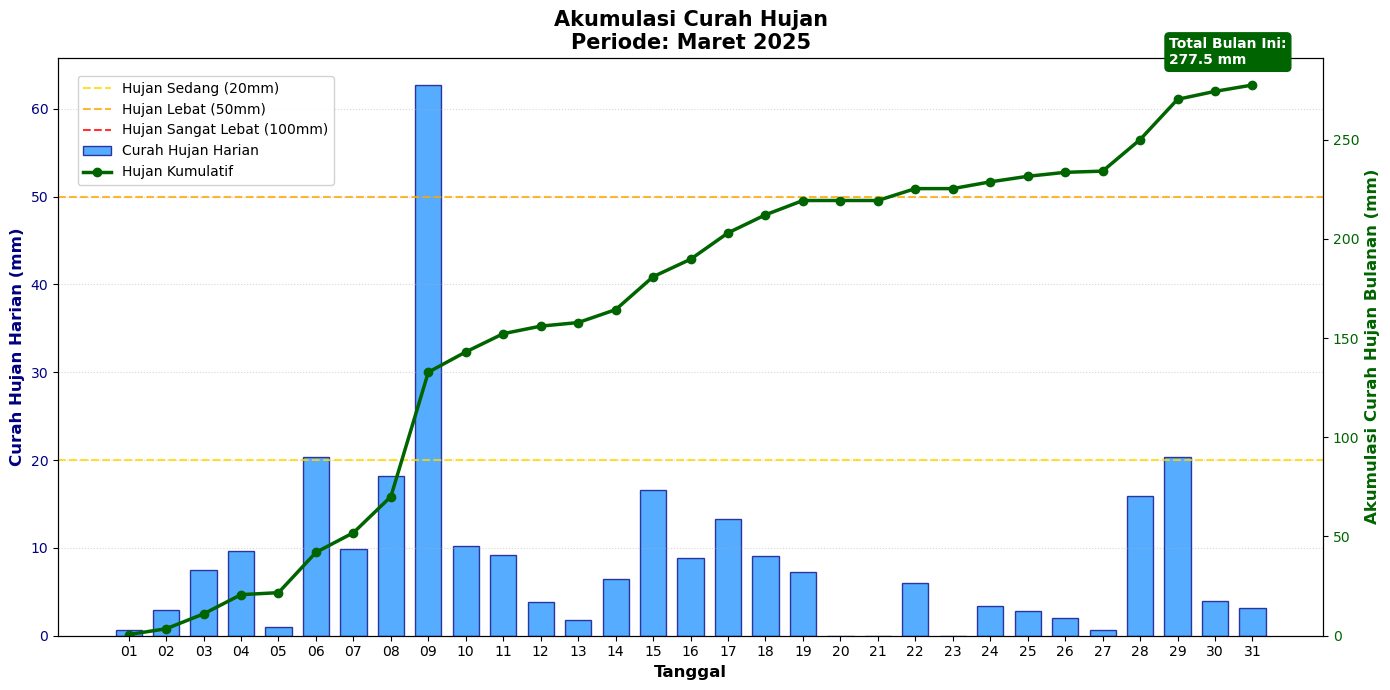


--- Memproses Data Bulan 2025-04 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-04...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-04.png


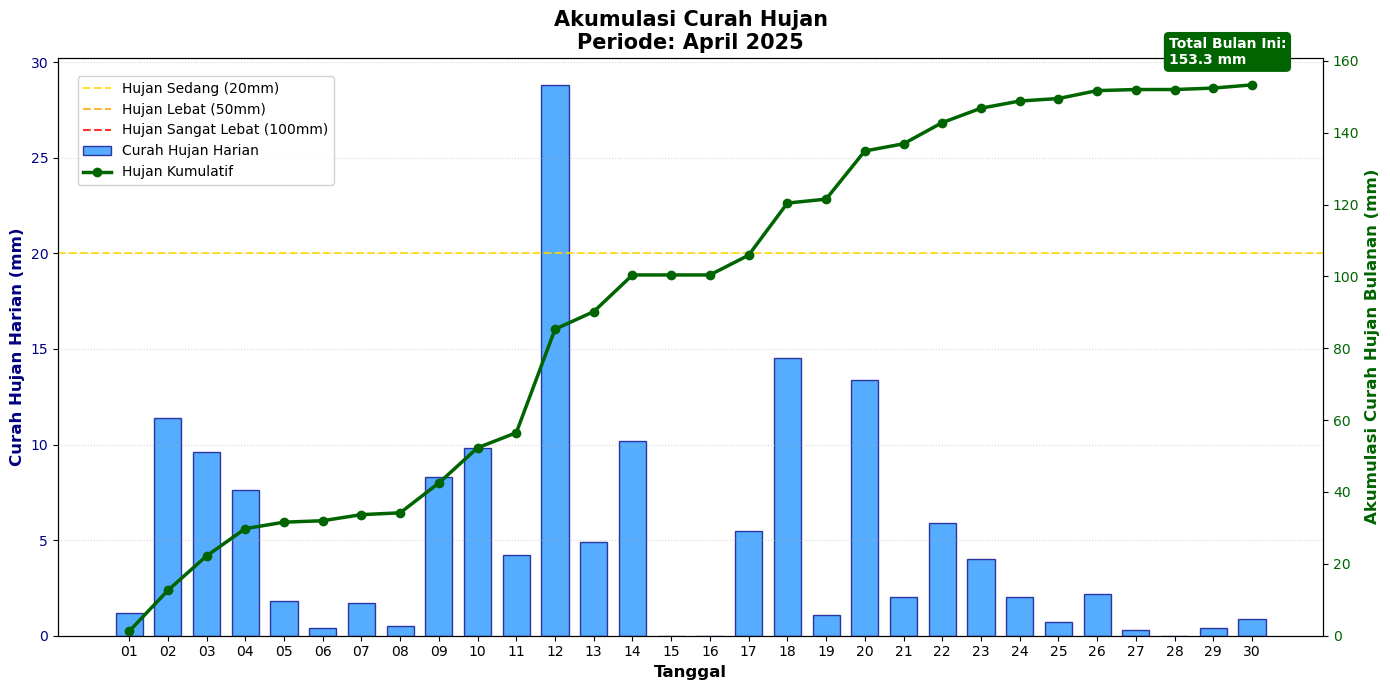


--- Memproses Data Bulan 2025-05 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-05...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-05.png


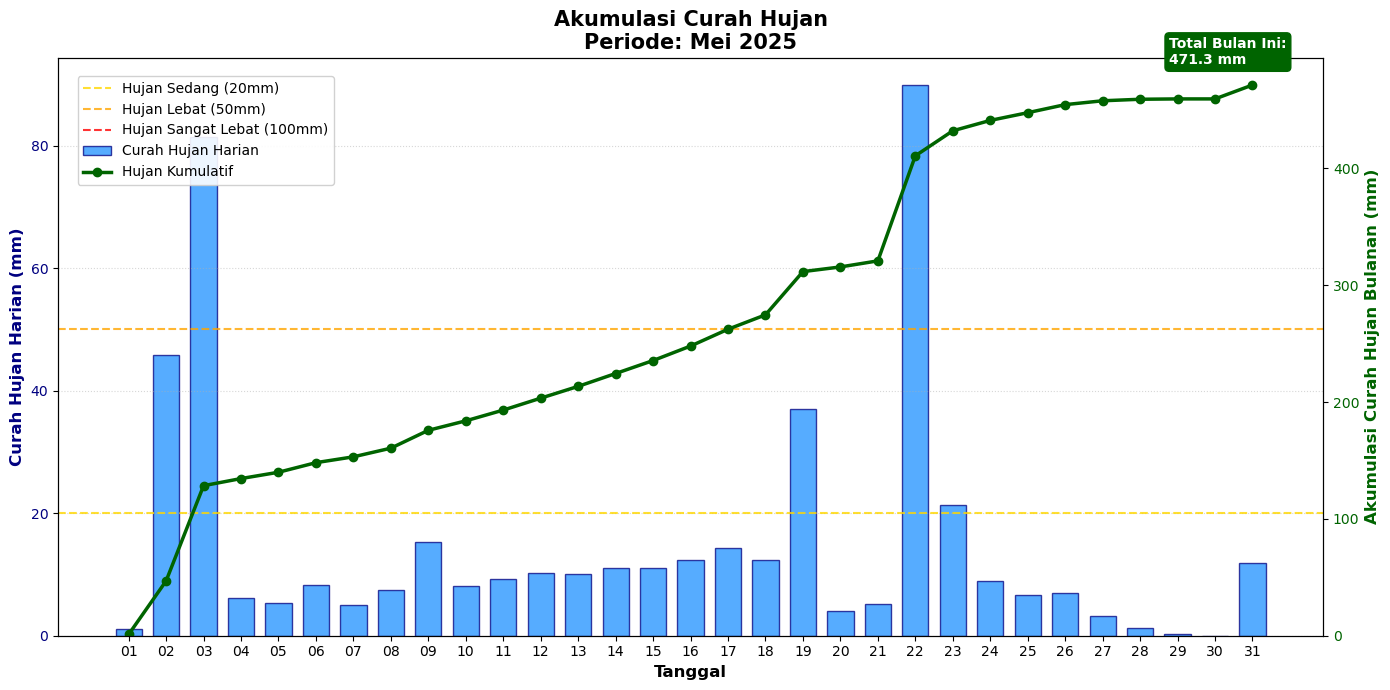


--- Memproses Data Bulan 2025-06 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-06...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-06.png


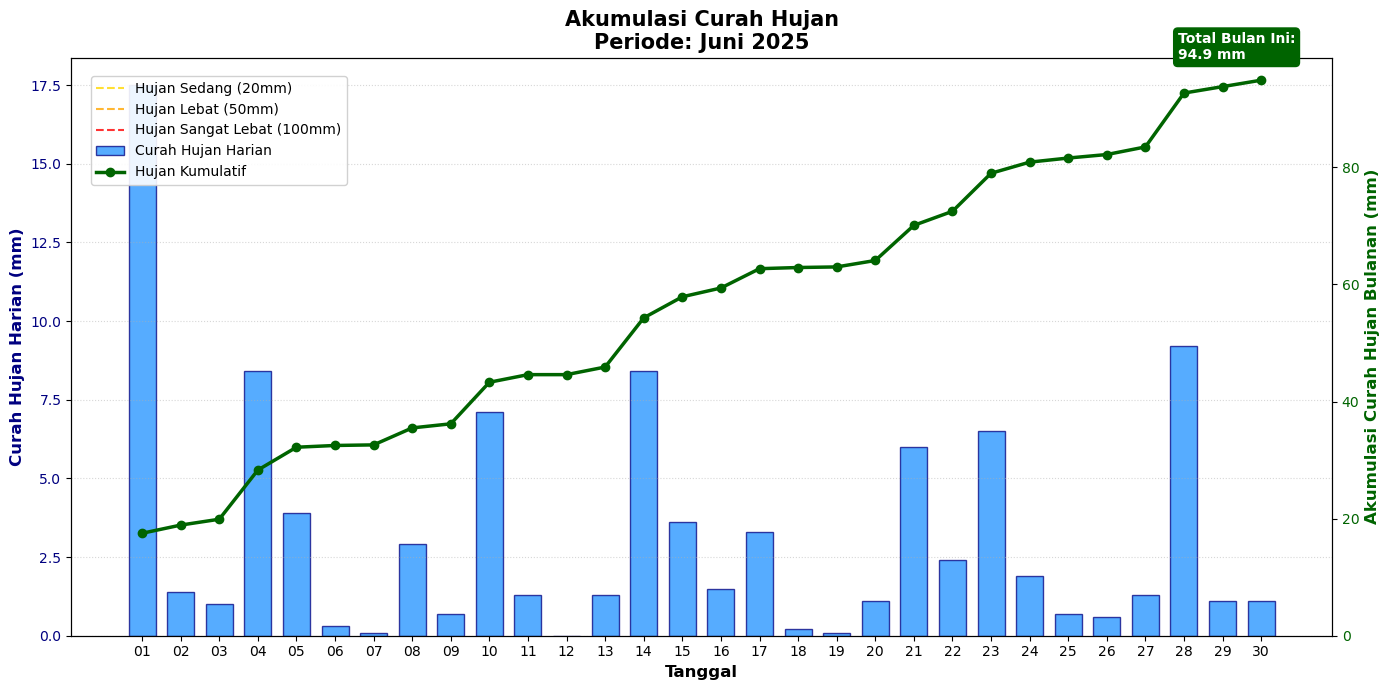


--- Memproses Data Bulan 2025-07 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-07...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-07.png


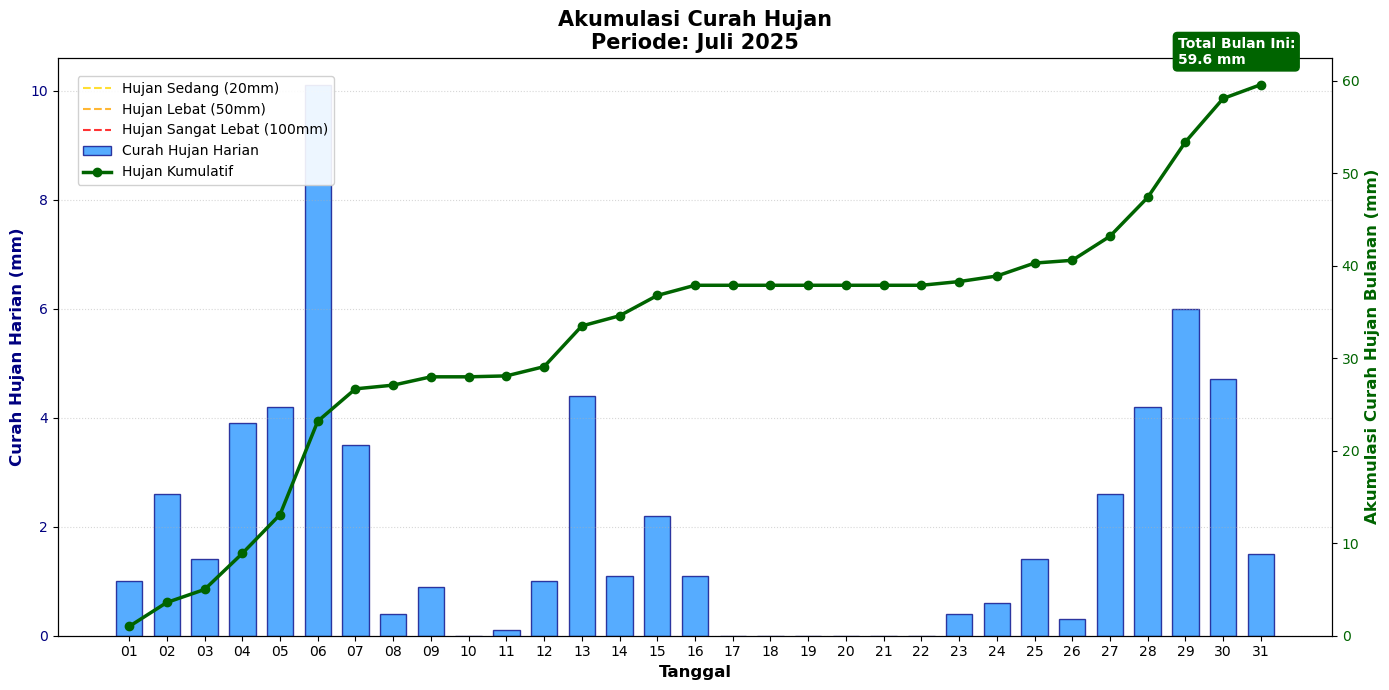


--- Memproses Data Bulan 2025-08 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-08...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-08.png


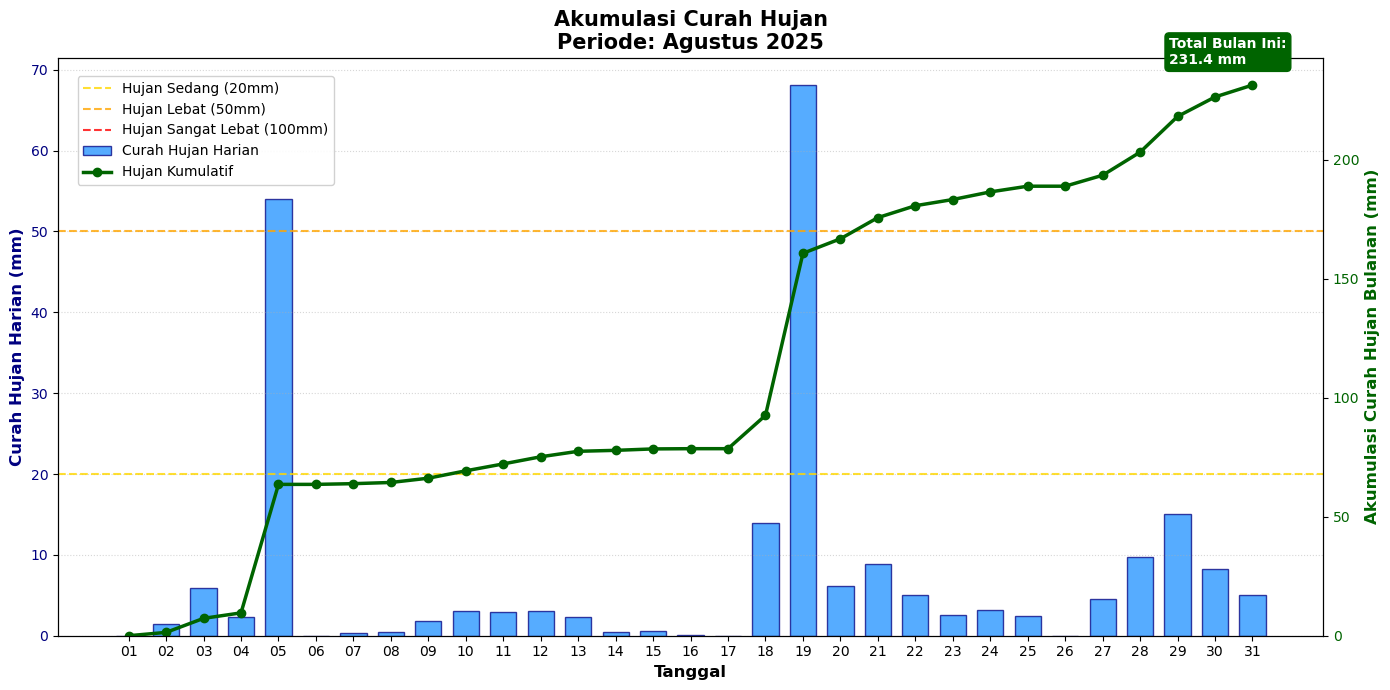


--- Memproses Data Bulan 2025-09 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-09...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-09.png


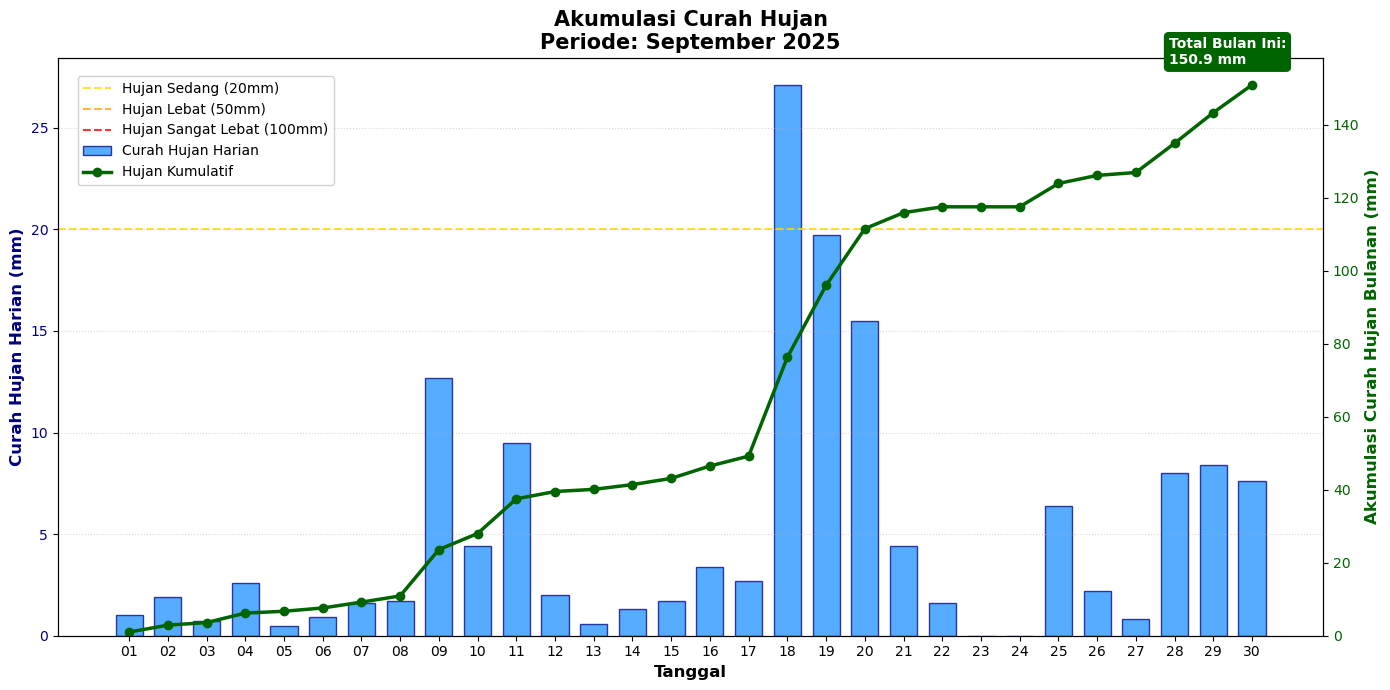


--- Memproses Data Bulan 2025-10 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-10...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-10.png


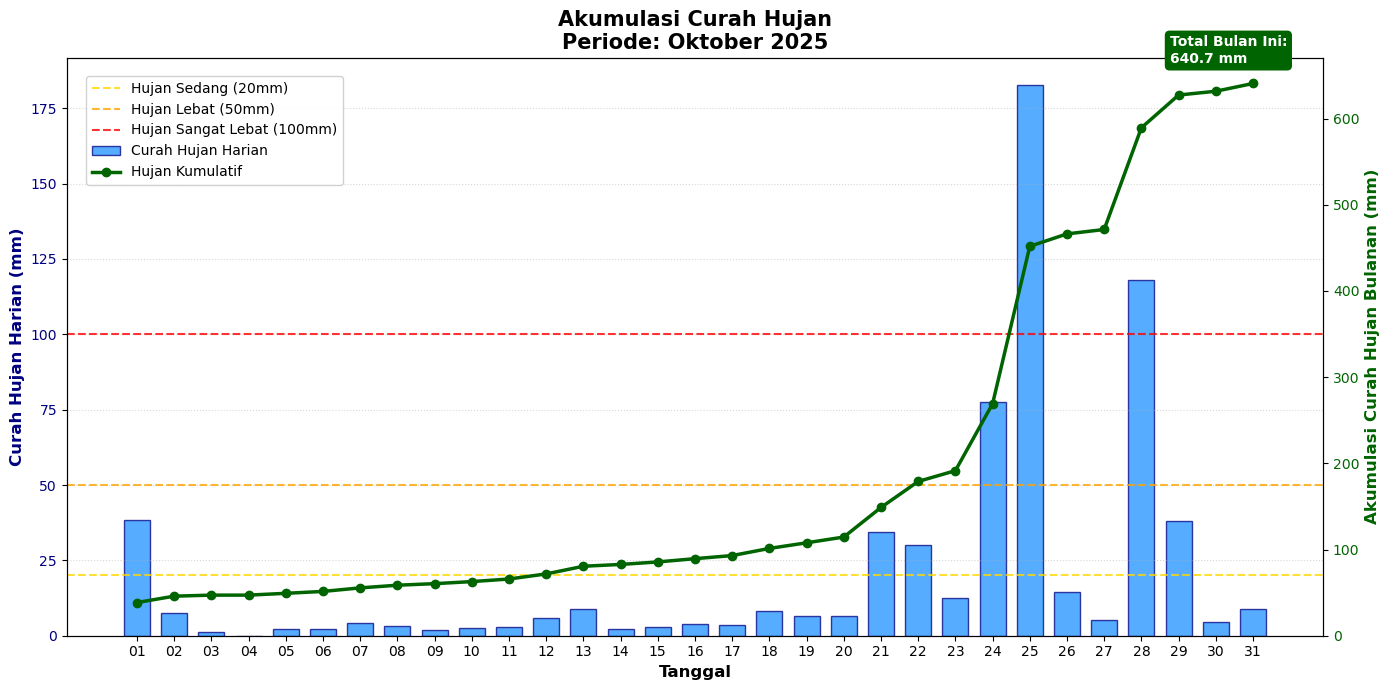


--- Memproses Data Bulan 2025-11 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-11...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-11.png


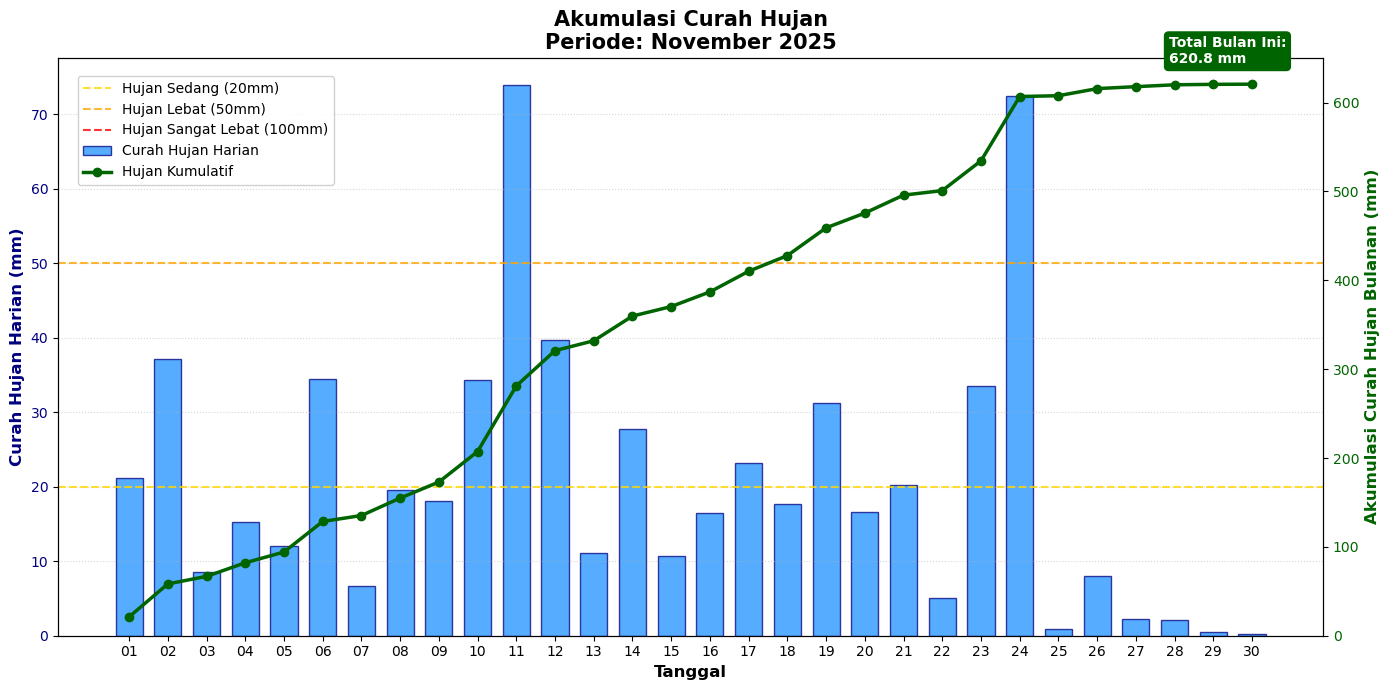


--- Memproses Data Bulan 2025-12 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2025-12...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2025-12.png


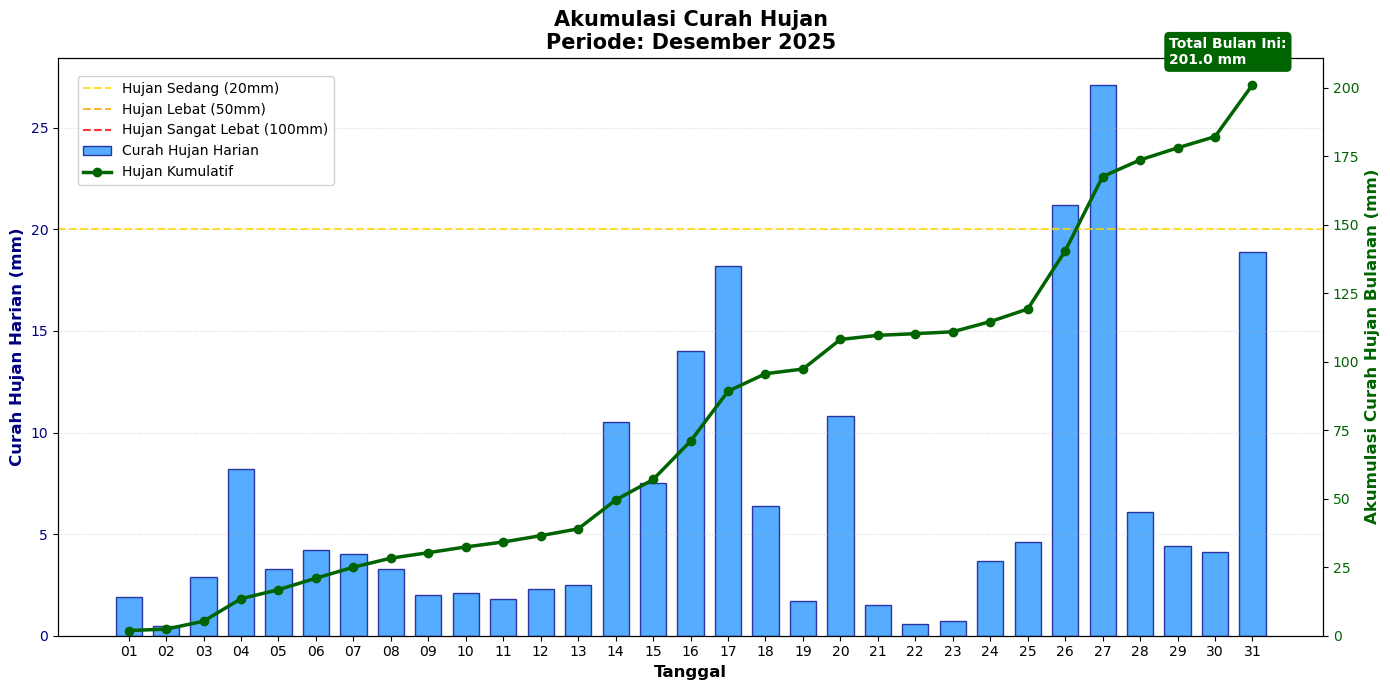


--- Memproses Data Bulan 2026-01 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2026-01...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2026-01.png


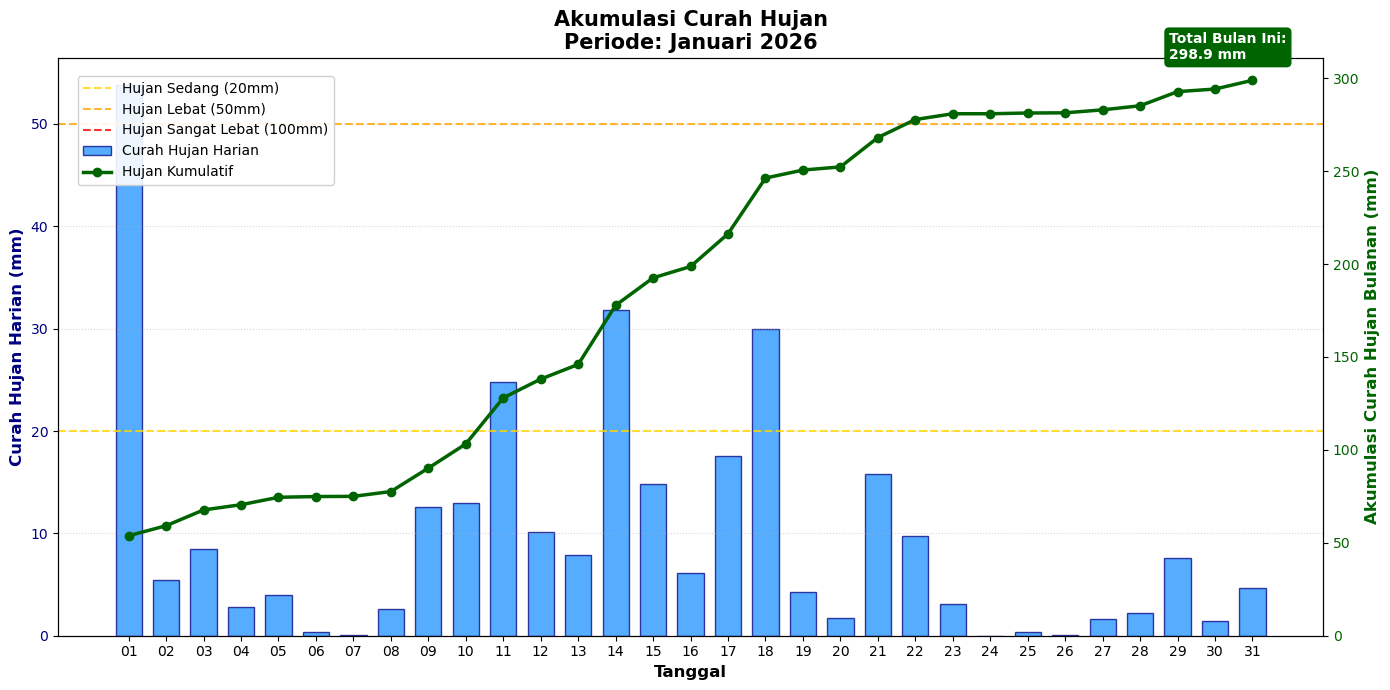


--- Memproses Data Bulan 2026-02 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2026-02...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2026-02.png


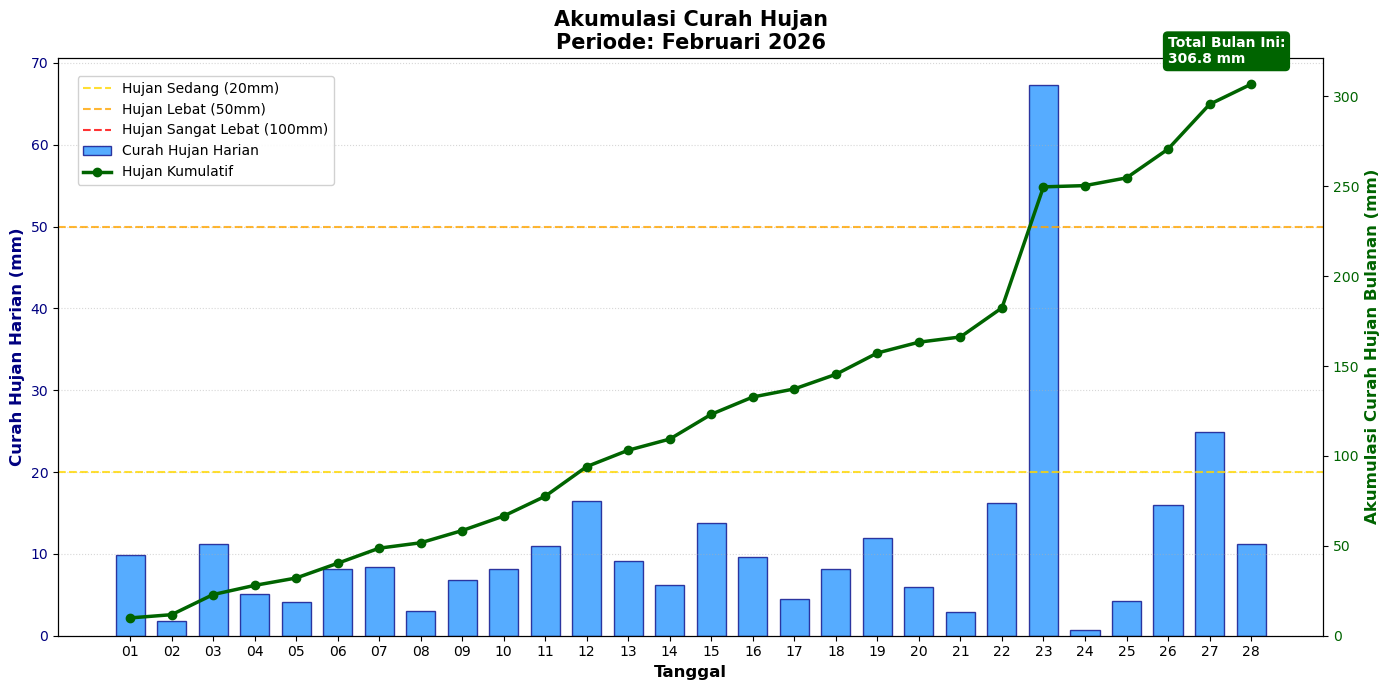


--- Memproses Data Bulan 2026-03 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2026-03...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2026-03.png


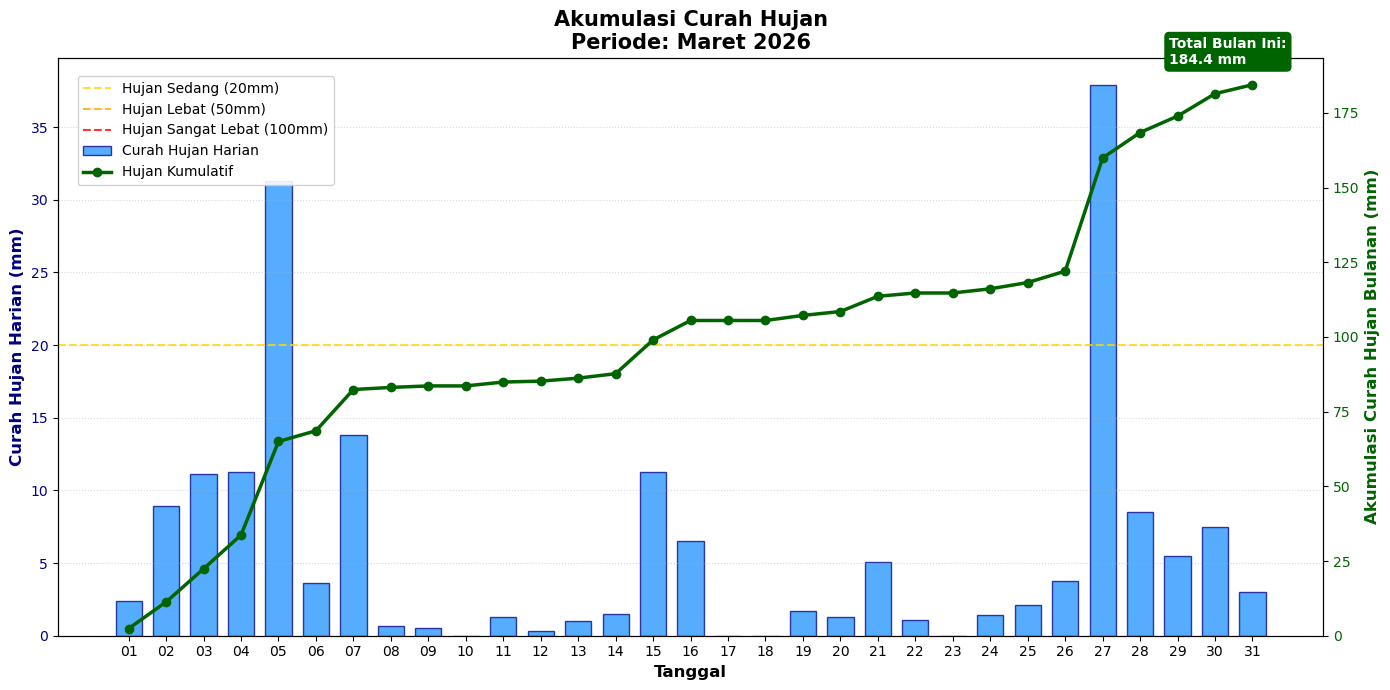


--- Memproses Data Bulan 2026-04 ---

🌧️ Membuat Hyetograph Bulanan untuk periode: 2026-04...
✅ Grafik Hyetograph berhasil disimpan di: plots_hyetograph_bulanan\Hyetograph_Bulanan_2026-04.png


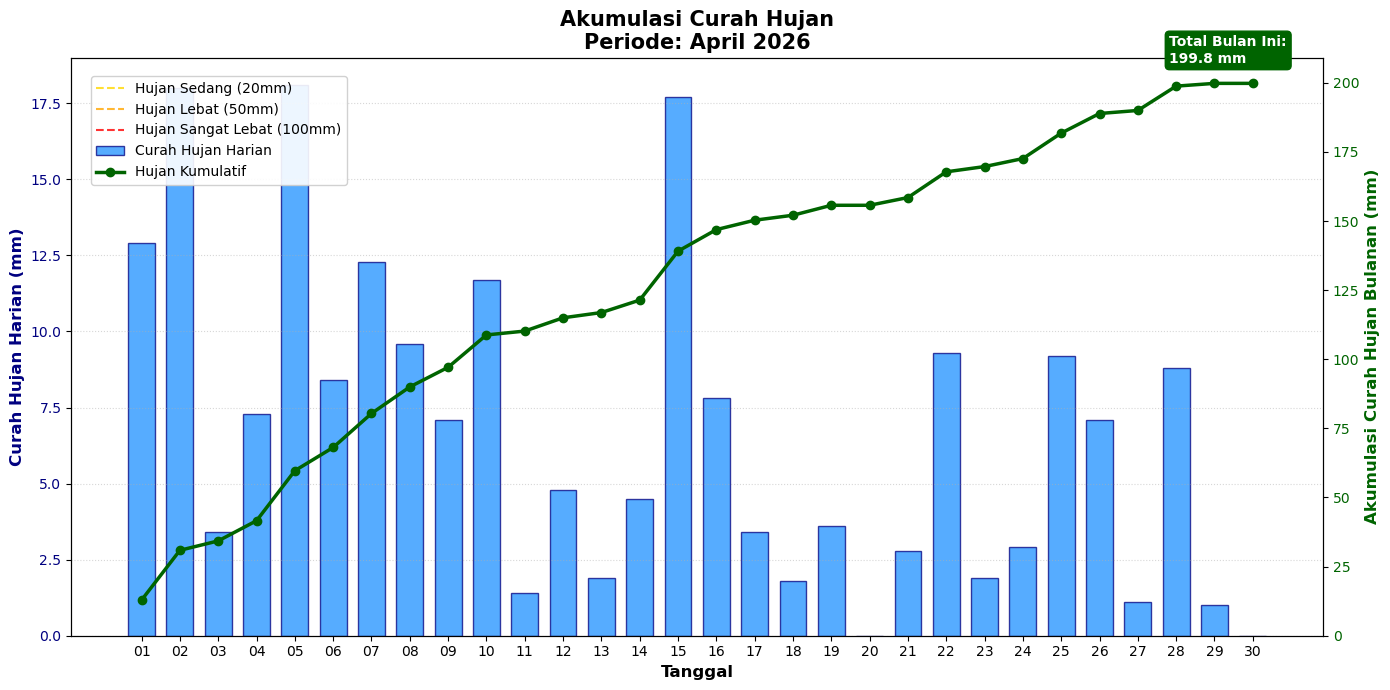

In [42]:
# 1. Deteksi environment (Kaggle vs Lokal)
cwd = os.getcwd()

if "/kaggle" in cwd:
    # Base folder jika dijalankan di Kaggle
    BASE_DIR = os.path.join("/kaggle", "input", "datasets", "jerismeteo", "open-meteo-data-kebumen")
else:
    # Base folder jika dijalankan di laptop/komputer lokal
    BASE_DIR = cwd

# 2. Tentukan nama sub-folder dan file
FOLDER_DATA = "open_meteo_jerukagung"
NAMA_FILE = "cuaca_jerukagung.csv"

# 3. Gabungkan semua bagian menjadi satu path yang dinamis dan aman (bebas slash/backslash error)
PATH_FILE = os.path.join(BASE_DIR, FOLDER_DATA, NAMA_FILE)

if __name__ == "__main__":
    df_cuaca = load_data(PATH_FILE)
    
    if df_cuaca is not None:
        # Ubah TARGET menjadi sebuah List berisi beberapa bulan
        TARGETS = [
            "2025-01", 
            "2025-02",
            "2025-03",
            "2025-04",
            "2025-05",
            "2025-06",
            "2025-07",
            "2025-08",
            "2025-09",
            "2025-10",
            "2025-11",
            "2025-12",
            "2026-01", 
            "2026-02", 
            "2026-03", 
            "2026-04"
            ]
        
        # Lakukan perulangan untuk setiap bulan di dalam list
        for target_bulan in TARGETS:
            print(f"\n--- Memproses Data Bulan {target_bulan} ---")
            plot_hyetograph_bulanan(df_cuaca, target_bulan)

In [43]:
# 1. Deteksi environment (Kaggle vs Lokal)
cwd = os.getcwd()

if "/kaggle" in cwd:
    # Base folder jika dijalankan di Kaggle
    BASE_DIR = os.path.join("/kaggle", "input", "datasets", "jerismeteo", "open-meteo-data-kebumen")
else:
    # Base folder jika dijalankan di laptop/komputer lokal
    BASE_DIR = cwd

# 2. Tentukan nama sub-folder dan file
FOLDER_DATA = "open_meteo_jerukagung"
NAMA_FILE = "cuaca_jerukagung.csv"

# 3. Gabungkan semua bagian menjadi satu path yang dinamis dan aman (bebas slash/backslash error)
PATH_FILE = os.path.join(BASE_DIR, FOLDER_DATA, NAMA_FILE)

print(f"Target lokasi file: {PATH_FILE}")

# =========================================================
# BLOK UTAMA
# =========================================================
if __name__ == "__main__":
    # Safety Check: Pastikan file benar-benar ada sebelum diproses
    if not os.path.exists(PATH_FILE):
        print(f"⚠️ ERROR: File tidak ditemukan di {PATH_FILE}")
        print("Silakan periksa kembali struktur direktori dataset Anda di Kaggle.")
    else:
        print("Sip, file ditemukan! Memulai analisis...")
        df_cuaca = load_data(PATH_FILE)
        
        if df_cuaca is not None:
            # Contoh Analisis YYYY-MM-DD (Satu Hari Penuh)
            TARGET = "2026-04-09"
            
            # 1. Tampilkan Angka Statistik
            analisis_detail(df_cuaca, TARGET)
            
            # 2. Tampilkan Grafik
            plot_harian(df_cuaca, TARGET)

Target lokasi file: d:\Github\Catatan_Meteorologi\Analisis_Meteorologi\open_meteo_jerukagung\cuaca_jerukagung.csv
Sip, file ditemukan! Memulai analisis...

ANALISIS DETAIL PERIODE: 2026-04-09
STATISTIK SUHU
Rata-rata Suhu Bulanan: 27.58°C
Suhu Maksimum: 30.85°C (pada 2026-04-09 14:00:00)
Suhu Minimum : 25.70°C (pada 2026-04-09 06:00:00)
------------------------------
Total Curah Hujan : 7.10 mm
Rekor Curah Hujan   : 7.10 mm (Tgl 2026-04-09)
Jumlah Hari Basah (>10mm)  : 0 hari
Jumlah Hari Kering (<=10mm): 1 hari


NameError: name 'plot_harian' is not defined